# Zomato Restaurant Clustering - Unsupervised Machine Learning

**Project Name:** Unsupervised ML - Zomato Restaurant Clustering  
Contribution - Individual

**Student:** Katepally Nandeeshwar Reddy

## Project Summary

In this project, I worked with Zomato restaurant information and customer reviews. I first explored the data, cleaned the fields that were needed, and looked at the main patterns through charts. I also used the review text to get a simple sentiment score for each review.

The main ML task is **restaurant segmentation**. Since there is no target column that tells us the correct segment, I treated it as an unsupervised learning problem. I created restaurant-level features such as cost, rating, review activity and sentiment, then compared K-Means, Agglomerative Clustering and Gaussian Mixture models.

The final goal is not only to create clusters, but also to explain what each group looks like and how the results could be useful to Zomato.

## GitHub Link

https://github.com/nandhu6143/zomato-restaurant-clustering

## Problem Statement

Zomato has restaurants with different prices, cuisines, ratings and customer experiences. A simple list of restaurants does not show these differences very clearly. The aim of this project is to find natural groups of similar restaurants using the available restaurant and review data.

The analysis also looks at customer sentiment so that the restaurant segments are based on more than just star ratings. The final clusters can be used for restaurant discovery, recommendations, promotions and identifying areas where customer experience may need improvement.

## General Guidelines - Project Implementation Notes

- I have kept the code in separate sections so that the notebook is easy to follow.
- Comments are added where the logic may not be obvious.
- File loading and text processing include basic error handling.
- The notebook is intended to run from top to bottom after the two CSV files are uploaded.
- Fixed random states are used where needed so that the ML results are reproducible.

## 1. Know Your Data

### Import Libraries

In [1]:
# Libraries
import os
import re
import warnings
import joblib
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# NLP
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning
from sklearn.preprocessing import StandardScaler, RobustScaler, MultiLabelBinarizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

### Dataset Loading

In [2]:
# Load the two CSV files.
# The notebook first checks the current directory and then /content for Google Colab.

restaurant_file = "Zomato Restaurant names and Metadata.csv"
review_file = "Zomato Restaurant reviews.csv"

def find_file(filename):
    candidates = [
        filename,
        os.path.join("/content", filename),
        os.path.join("/mnt/data", filename)
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    return None

restaurant_path = find_file(restaurant_file)
review_path = find_file(review_file)

if restaurant_path is None or review_path is None:
    raise FileNotFoundError(
        "Required CSV files were not found. Upload both CSV files and run this cell again."
    )

restaurants = pd.read_csv(restaurant_path)
reviews = pd.read_csv(review_path)

print("Restaurant dataset loaded:", restaurants.shape)
print("Review dataset loaded:", reviews.shape)

Restaurant dataset loaded: (105, 6)
Review dataset loaded: (10000, 7)


### Dataset First View

In [3]:
# Check the first few rows.
print("Restaurant Dataset - First 5 Rows")
display(restaurants.head())

print("Review Dataset - First 5 Rows")
display(reviews.head())

Restaurant Dataset - First 5 Rows


,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavours-gachibowli,800,"Food Hygiene Rated Restaurants in Hyderabad, Corporate Favorites, Great Buffets, Top-Rated, Gold Curated, Live Sport...","Chinese, Continental, Kebab, European, South Indian, North Indian","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gachibowli,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gachibowli,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-hotel-restaurant-gachibowli,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Beverages",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon-brew-company-gachibowli,"1,200","Best Bars & Pubs, Food Hygiene Rated Restaurants in Hyderabad, Top-Rated, Gold Curated, Hyderabad's Hottest","Asian, Continental, North Indian, Chinese, Mediterranean","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12noon to 12midnight (Fri-Sat)"


Review Dataset - First 5 Rows


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate ...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soume...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx for the service by Pradeep and Subroto. My personal recommendation is P...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,"Soumen das and Arun was a great guy. Only because of their behavior and sincerety, And good food off course, I would...",5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and basket mutton biryani. All are good. Thanks to Pradeep. He served well. ...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### Dataset Rows & Columns count

In [4]:
# Check dataset size.
print(f"Restaurant dataset: {restaurants.shape[0]} rows and {restaurants.shape[1]} columns")
print(f"Review dataset: {reviews.shape[0]} rows and {reviews.shape[1]} columns")

Restaurant dataset: 105 rows and 6 columns
Review dataset: 10000 rows and 7 columns


### Dataset Information

In [5]:
# Check column types and missing data.
print("Restaurant Dataset Information")
restaurants.info()

print("\nReview Dataset Information")
reviews.info()

Restaurant Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB

Review Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dt

#### Duplicate Values

In [6]:
# Count duplicate rows.
print("Restaurant duplicate rows:", restaurants.duplicated().sum())
print("Review duplicate rows:", reviews.duplicated().sum())

Restaurant duplicate rows: 0
Review duplicate rows: 36


#### Missing Values/Null Values

In [7]:
# Count missing values in each column.
restaurant_missing = restaurants.isna().sum().sort_values(ascending=False)
review_missing = reviews.isna().sum().sort_values(ascending=False)

print("Restaurant missing values")
display(restaurant_missing.to_frame("Missing_Count"))

print("Review missing values")
display(review_missing.to_frame("Missing_Count"))

Restaurant missing values


,Missing_Count
Collections,54
Timings,1
Links,0
Name,0
Cost,0
Cuisines,0


Review missing values


,Missing_Count
Review,45
Reviewer,38
Rating,38
Time,38
Metadata,38
Restaurant,0
Pictures,0


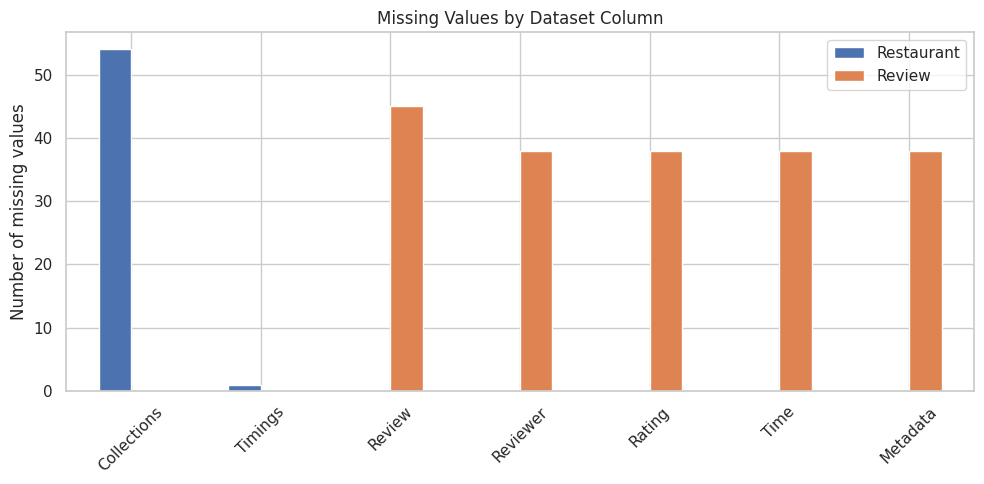

In [8]:
# Visualize missing values using a simple bar chart.
missing_all = pd.concat([
    restaurant_missing[restaurant_missing > 0].rename("Restaurant"),
    review_missing[review_missing > 0].rename("Review")
], axis=1).fillna(0)

if missing_all.empty:
    print("No missing values found.")
else:
    missing_all.plot(kind="bar", figsize=(10, 5))
    plt.title("Missing Values by Dataset Column")
    plt.ylabel("Number of missing values")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### What did you know about your dataset?

After the first inspection, I found that the restaurant metadata has **105 rows and 6 columns**, while the review dataset has **10,000 rows and 7 columns**.

The restaurant file mainly describes the restaurants themselves: name, link, cost, collections, cuisines and timings. The review file gives customer-level information such as the restaurant name, reviewer, review text, rating, metadata, review time and pictures.

One important point is that the two files are at different levels. The restaurant file is restaurant-level data, while the review file is review-level data. So before clustering, I need to aggregate the review information back to restaurant level.

## 2. Understanding Your Variables

In [9]:
# Display all dataset columns and their data types.
print("Restaurant columns:")
display(pd.DataFrame({
    "Column": restaurants.columns,
    "Data_Type": restaurants.dtypes.astype(str).values
}))

print("Review columns:")
display(pd.DataFrame({
    "Column": reviews.columns,
    "Data_Type": reviews.dtypes.astype(str).values
}))

Restaurant columns:


,Column,Data_Type
0,Name,object
1,Links,object
2,Cost,object
3,Collections,object
4,Cuisines,object
5,Timings,object


Review columns:


,Column,Data_Type
0,Restaurant,object
1,Reviewer,object
2,Review,object
3,Rating,object
4,Metadata,object
5,Time,object
6,Pictures,int64


### Dataset Describe

In [10]:
# Describe numerical and categorical variables.
print("Restaurant descriptive statistics")
display(restaurants.describe(include="all").T)

print("Review descriptive statistics")
display(reviews.describe(include="all").T)

Restaurant descriptive statistics


,count,unique,top,freq
Name,105,105,Beyond Flavours,1
Links,105,105,https://www.zomato.com/hyderabad/beyond-flavours-gachibowli,1
Cost,105,29,500,13
Collections,51,42,Food Hygiene Rated Restaurants in Hyderabad,4
Cuisines,105,92,"North Indian, Chinese",4
Timings,104,77,11 AM to 11 PM,6


Review descriptive statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Restaurant,10000,100,Beyond Flavours,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reviewer,9962,7446,Parijat Ray,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review,9955,9364,good,237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9962,10,5,3832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Metadata,9962,2477,1 Review,919,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time,9962,9782,7/29/2018 20:34,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pictures,10000.0,NaN,NaN,NaN,0.7486,2.570381,0.0,0.0,0.0,0.0,64.0


### Variables Description

**Restaurant dataset**
- `Name`: restaurant name.
- `Links`: restaurant URL.
- `Cost`: estimated cost of dining per person.
- `Collections`: Zomato collection/category tags.
- `Cuisines`: cuisines served by the restaurant.
- `Timings`: restaurant operating timings.

**Review dataset**
- `Restaurant`: restaurant associated with the review.
- `Reviewer`: reviewer name.
- `Review`: customer review text.
- `Rating`: rating supplied by the reviewer.
- `Metadata`: reviewer review/follower information.
- `Time`: date and time of review.
- `Pictures`: number of pictures posted with the review.

### Check Unique Values for each variable.

In [11]:
# Check unique counts for every column.
unique_summary = []
for df_name, df in [("Restaurants", restaurants), ("Reviews", reviews)]:
    for col in df.columns:
        unique_summary.append({
            "Dataset": df_name,
            "Column": col,
            "Unique_Values": df[col].nunique(dropna=True),
            "Missing": df[col].isna().sum()
        })

display(pd.DataFrame(unique_summary))

,Dataset,Column,Unique_Values,Missing
0,Restaurants,Name,105,0
1,Restaurants,Links,105,0
2,Restaurants,Cost,29,0
3,Restaurants,Collections,42,54
4,Restaurants,Cuisines,92,0
5,Restaurants,Timings,77,1
6,Reviews,Restaurant,100,0
7,Reviews,Reviewer,7446,38
8,Reviews,Review,9364,45
9,Reviews,Rating,10,38


## 3. Data Wrangling

### Data Wrangling Code

In [12]:
# -----------------------------
# 1. Remove exact duplicates
# -----------------------------
restaurants = restaurants.drop_duplicates().reset_index(drop=True)
reviews = reviews.drop_duplicates().reset_index(drop=True)

# -----------------------------
# 2. Clean restaurant cost
# -----------------------------
restaurants["Cost_num"] = (
    restaurants["Cost"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
    .astype(float)
)

# -----------------------------
# 3. Clean multi-label text fields
# -----------------------------
for col in ["Collections", "Cuisines", "Timings"]:
    restaurants[col] = restaurants[col].fillna("").astype(str).str.strip()

restaurants["cuisine_count"] = restaurants["Cuisines"].apply(
    lambda x: len([item for item in x.split(",") if item.strip()])
)
restaurants["collection_count"] = restaurants["Collections"].apply(
    lambda x: len([item for item in x.split(",") if item.strip()])
)
restaurants["timing_count"] = restaurants["Timings"].apply(
    lambda x: len([item for item in x.split(",") if item.strip()])
)

# -----------------------------
# 4. Clean review columns
# -----------------------------
reviews["Review"] = reviews["Review"].fillna("").astype(str)
reviews["Reviewer"] = reviews["Reviewer"].fillna("Unknown Reviewer").astype(str)
reviews["Metadata"] = reviews["Metadata"].fillna("").astype(str)
reviews["Pictures"] = pd.to_numeric(reviews["Pictures"], errors="coerce").fillna(0)
reviews["Rating_num"] = pd.to_numeric(reviews["Rating"], errors="coerce")
reviews["Time_dt"] = pd.to_datetime(reviews["Time"], errors="coerce")

# Keep only rows with valid restaurant names.
reviews = reviews[reviews["Restaurant"].notna()].copy()

print("Cleaned restaurant shape:", restaurants.shape)
print("Cleaned review shape:", reviews.shape)
print("Non-numeric/missing ratings converted to NaN:", reviews["Rating_num"].isna().sum())

Cleaned restaurant shape: (105, 10)
Cleaned review shape: (9964, 9)
Non-numeric/missing ratings converted to NaN: 3


### What all manipulations have you done and insights you found?

I made the following changes before using the data for analysis:

1. Removed exact duplicate rows.
2. Converted `Cost` into a numeric column.
3. Filled missing text/categorical fields with an empty value where appropriate.
4. Created counts for cuisines, collections and timings.
5. Converted ratings and picture counts to numeric values.
6. Converted the review time column to datetime.
7. Cleaned the review text and calculated sentiment scores.
8. Aggregated review information such as average rating, review count and sentiment at restaurant level.
9. Kept restaurants without reviews for the general EDA, but did not invent review information for them during clustering.

This gives me one usable row per restaurant for the clustering stage.

## 4. Data Visualization, Storytelling & Experimenting with Charts

I followed the **UBM rule** while selecting the charts:

- **U - Univariate:** understand one variable at a time.
- **B - Bivariate:** compare two variables.
- **M - Multivariate:** look at several variables together.

For every chart, I have added a short explanation of why I used it, what I noticed and how the finding could be useful for the business.

#### Chart - 1

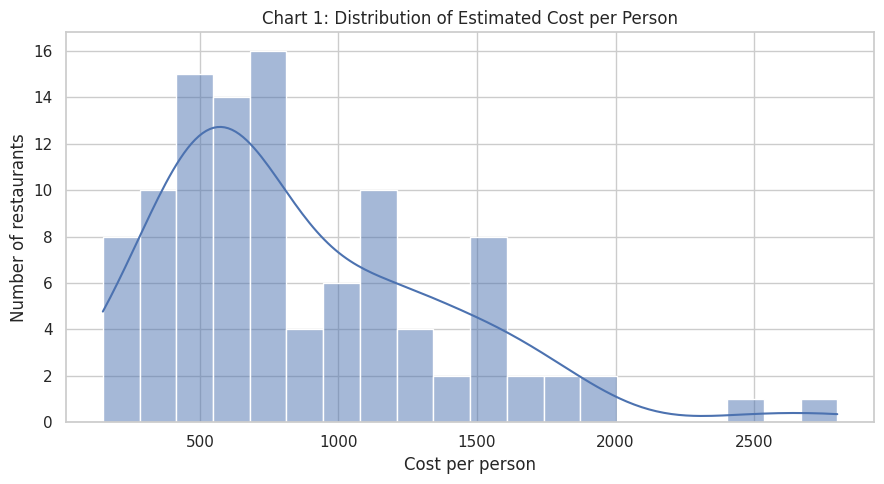

In [13]:
# Chart - 1 visualization code: Restaurant Cost Distribution
plt.figure(figsize=(9, 5))
sns.histplot(restaurants["Cost_num"].dropna(), bins=20, kde=True, color="C0")
plt.title("Chart 1: Distribution of Estimated Cost per Person")
plt.xlabel("Cost per person")
plt.ylabel("Number of restaurants")
plt.tight_layout()
plt.show()

**Why I used it:** Cost is a single numerical variable, so a histogram is a simple way to see its spread.

**What I noticed:** The chart shows where most restaurants fall in terms of price and whether there are a few much more expensive restaurants.

**Why it matters:** This can help with price-based filters and with separating value restaurants from premium restaurants.

#### Chart - 2

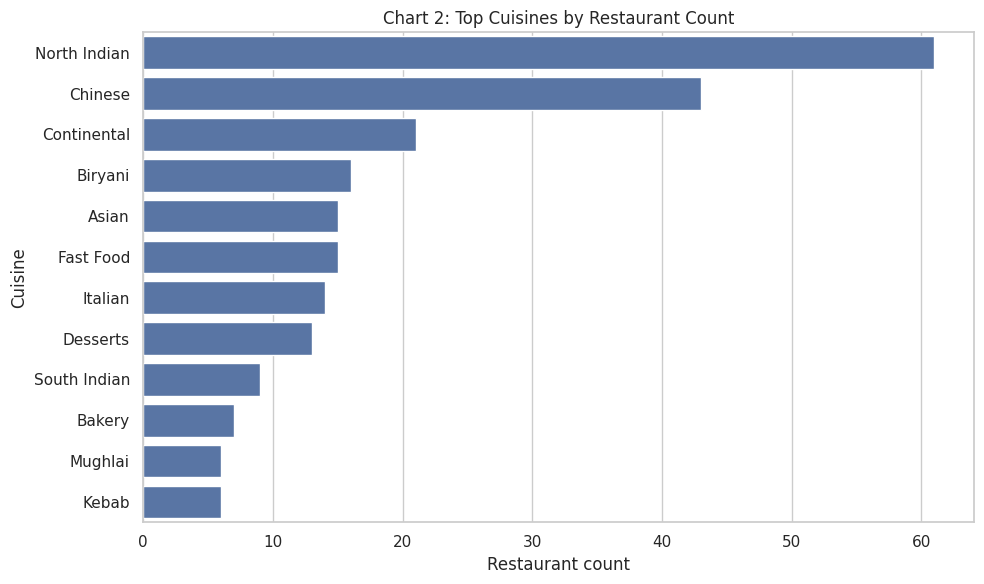

In [14]:
# Chart - 2 visualization code: Top Cuisines
cuisine_series = (
    restaurants["Cuisines"].str.split(",").explode().str.strip()
    .replace("", np.nan).dropna()
)
top_cuisines = cuisine_series.value_counts().head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, color="C0")
plt.title("Chart 2: Top Cuisines by Restaurant Count")
plt.xlabel("Restaurant count")
plt.ylabel("Cuisine")
plt.tight_layout()
plt.show()

**Why I used it:** A horizontal bar chart makes it easy to compare the number of restaurants across cuisines.

**What I noticed:** A few cuisines appear much more often than the others in this dataset.

**Why it matters:** Popular cuisines can be useful for search filters, promotions and category recommendations.

#### Chart - 3

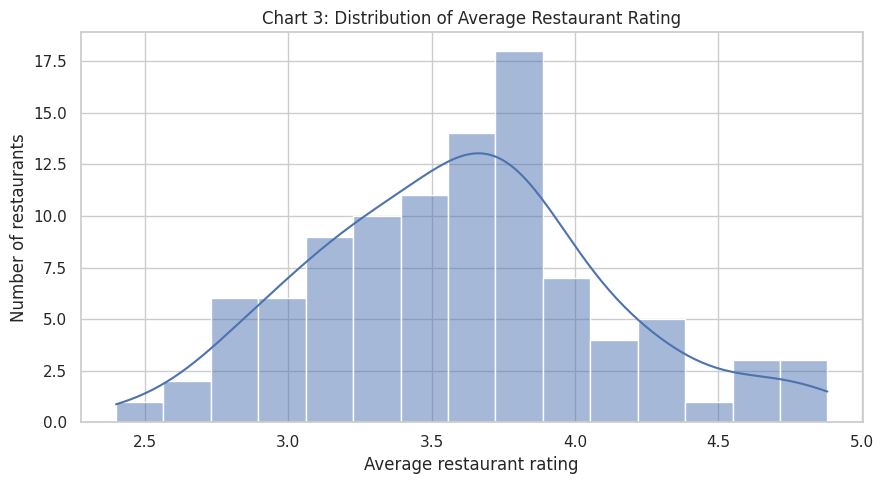

In [15]:
# Chart - 3 visualization code: Rating Distribution
review_rating_df = reviews.dropna(subset=["Rating_num"]).copy()
restaurant_rating = review_rating_df.groupby("Restaurant")["Rating_num"].mean()

plt.figure(figsize=(9, 5))
sns.histplot(restaurant_rating, bins=15, kde=True, color="C0")
plt.title("Chart 3: Distribution of Average Restaurant Rating")
plt.xlabel("Average restaurant rating")
plt.ylabel("Number of restaurants")
plt.tight_layout()
plt.show()

**Why I used it:** A histogram gives a quick view of how restaurant ratings are distributed.

**What I noticed:** It shows whether the ratings are mostly high, moderate or spread out.

**Why it matters:** A restaurant with a low rating can be flagged for further review, while consistently high-rated restaurants can be highlighted to customers.

#### Chart - 4

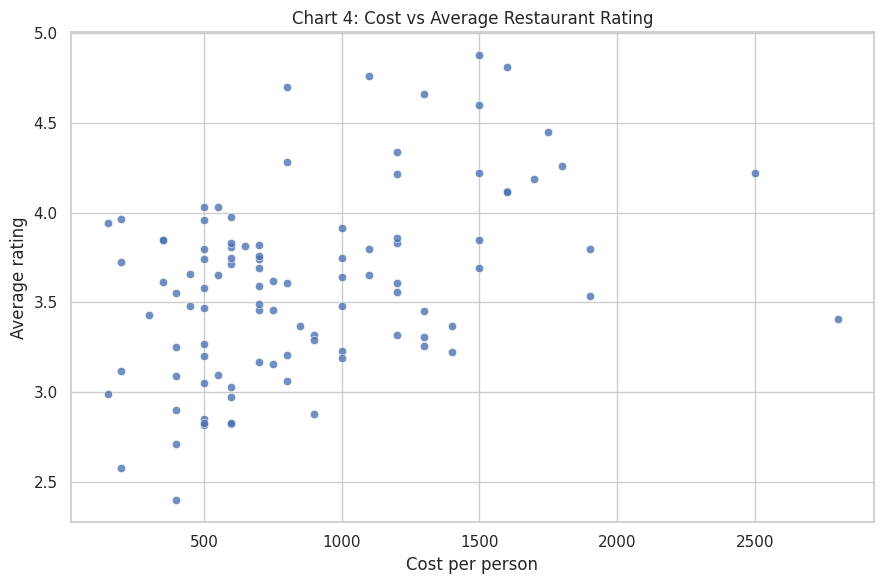

In [16]:
# Chart - 4 visualization code: Cost vs Average Rating
rating_agg = reviews.groupby("Restaurant")["Rating_num"].mean().rename("avg_rating")
eda_df = restaurants.merge(rating_agg, left_on="Name", right_index=True, how="inner")

plt.figure(figsize=(9, 6))
sns.scatterplot(data=eda_df, x="Cost_num", y="avg_rating", alpha=0.8, color="C0")
plt.title("Chart 4: Cost vs Average Restaurant Rating")
plt.xlabel("Cost per person")
plt.ylabel("Average rating")
plt.tight_layout()
plt.show()

**Why I used it:** I wanted to check whether price and rating move together, so a scatter plot is a good fit.

**What I noticed:** Higher price does not automatically mean a higher rating. There are restaurants that offer strong ratings at lower prices as well.

**Why it matters:** This can help identify good-value restaurants and also spots where a premium price may not match customer expectations.

#### Chart - 5

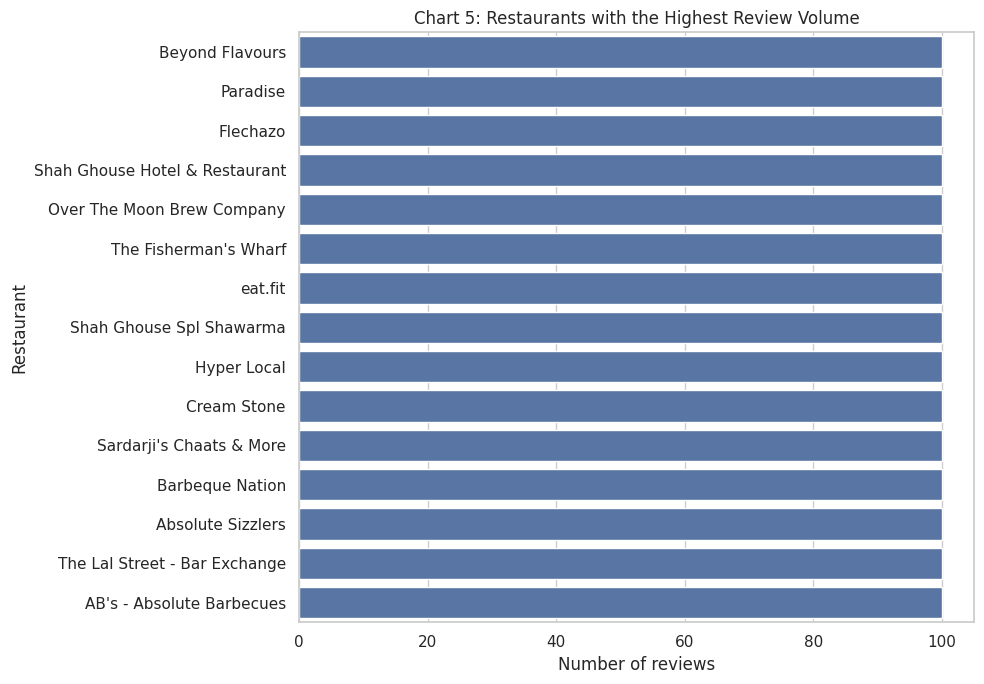

In [17]:
# Chart - 5 visualization code: Review Volume
review_counts = reviews["Restaurant"].value_counts().head(15).sort_values()

plt.figure(figsize=(10, 7))
sns.barplot(x=review_counts.values, y=review_counts.index, color="C0")
plt.title("Chart 5: Restaurants with the Highest Review Volume")
plt.xlabel("Number of reviews")
plt.ylabel("Restaurant")
plt.tight_layout()
plt.show()

**Why I used it:** A ranked bar chart makes the most-reviewed restaurants easy to spot.

**What I noticed:** Review activity is not evenly spread across all restaurants.

**Why it matters:** Restaurants with a lot of reviews have strong customer engagement, but review count alone should not be treated as proof of good quality.

In [18]:
# Prepare clean review text and sentiment before sentiment charts.
STOPWORDS = {
    "a","an","the","and","or","but","if","then","than","to","of","in","on","for",
    "with","is","was","were","are","am","be","been","this","that","it","as","at",
    "by","from","very","too","so","we","you","i","my","our","they","their","he",
    "she","his","her","have","has","had","not","no","do","does","did"
}

CONTRACTIONS = {
    "can't": "cannot", "won't": "will not", "don't": "do not", "didn't": "did not",
    "isn't": "is not", "wasn't": "was not", "aren't": "are not", "couldn't": "could not",
    "wouldn't": "would not", "shouldn't": "should not", "it's": "it is", "that's": "that is"
}

def expand_contractions(text):
    text = str(text)
    for contraction, expanded in CONTRACTIONS.items():
        text = re.sub(r"\b" + re.escape(contraction) + r"\b", expanded, text, flags=re.I)
    return text

def clean_text(text):
    text = expand_contractions(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\b\w*\d\w*\b", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [t for t in text.split() if t not in STOPWORDS]
    return " ".join(tokens)

reviews["Review_clean"] = reviews["Review"].apply(clean_text)

def safe_polarity(text):
    if not str(text).strip():
        return np.nan
    try:
        return TextBlob(text).sentiment.polarity
    except Exception:
        return np.nan

reviews["sentiment"] = reviews["Review"].apply(safe_polarity)
reviews["sentiment_label"] = pd.cut(
    reviews["sentiment"],
    bins=[-np.inf, -0.05, 0.05, np.inf],
    labels=["Negative", "Neutral", "Positive"]
)

review_agg = reviews.groupby("Restaurant").agg(
    avg_rating=("Rating_num", "mean"),
    review_count=("Review", "count"),
    avg_sentiment=("sentiment", "mean"),
    sentiment_std=("sentiment", "std"),
    positive_review_pct=("sentiment_label", lambda x: (x == "Positive").mean() * 100),
    negative_review_pct=("sentiment_label", lambda x: (x == "Negative").mean() * 100),
    total_pictures=("Pictures", "sum"),
    avg_pictures=("Pictures", "mean")
).reset_index()

print("Sentiment prepared. Review-level rows:", len(reviews))

Sentiment prepared. Review-level rows: 9964


#### Chart - 6

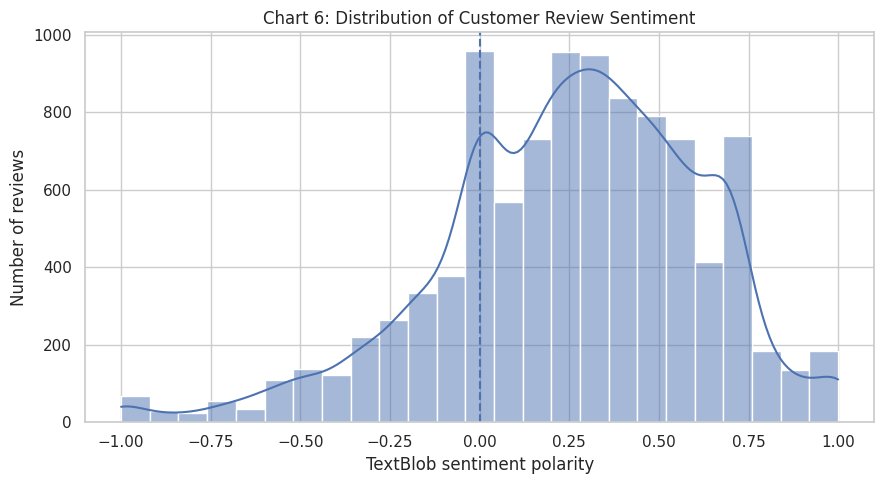

In [19]:
# Chart - 6 visualization code: Sentiment Distribution
plt.figure(figsize=(9, 5))
sns.histplot(reviews["sentiment"].dropna(), bins=25, kde=True, color="C0")
plt.axvline(0, linestyle="--")
plt.title("Chart 6: Distribution of Customer Review Sentiment")
plt.xlabel("TextBlob sentiment polarity")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.show()

**Why I used it:** Sentiment is a continuous score, so a histogram shows the overall shape clearly.

**What I noticed:** The chart shows how often reviews fall on the negative, neutral and positive side.

**Why it matters:** Sentiment can reveal customer experience issues that may not be obvious from the rating column alone.

#### Chart - 7

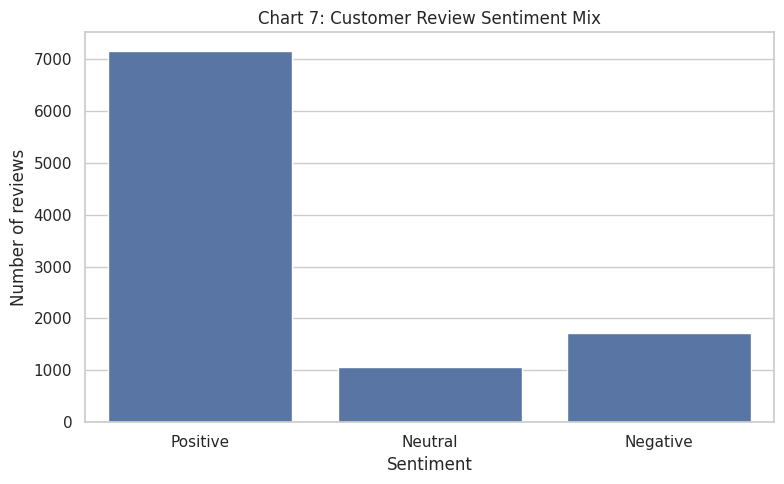

In [20]:
# Chart - 7 visualization code: Sentiment Mix
sent_counts = reviews["sentiment_label"].value_counts().reindex(
    ["Positive", "Neutral", "Negative"], fill_value=0
)

plt.figure(figsize=(8, 5))
sns.barplot(x=sent_counts.index, y=sent_counts.values, color="C0")
plt.title("Chart 7: Customer Review Sentiment Mix")
plt.xlabel("Sentiment")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.show()

**Why I used it:** A bar chart is the easiest way to compare positive, neutral and negative reviews.

**What I noticed:** It gives a quick picture of the overall sentiment mix in the review data.

**Why it matters:** Negative sentiment can be used as a signal for checking food quality, service or other recurring complaints.

In [21]:
# Merge restaurant metadata with review aggregates for restaurant-level analysis.
data = restaurants.merge(
    review_agg,
    left_on="Name",
    right_on="Restaurant",
    how="left"
)

# Review-dependent ML dataset: only restaurants having review records.
model_data = data[data["review_count"].fillna(0) > 0].copy()
model_data["sentiment_std"] = model_data["sentiment_std"].fillna(0)

#### Chart - 8

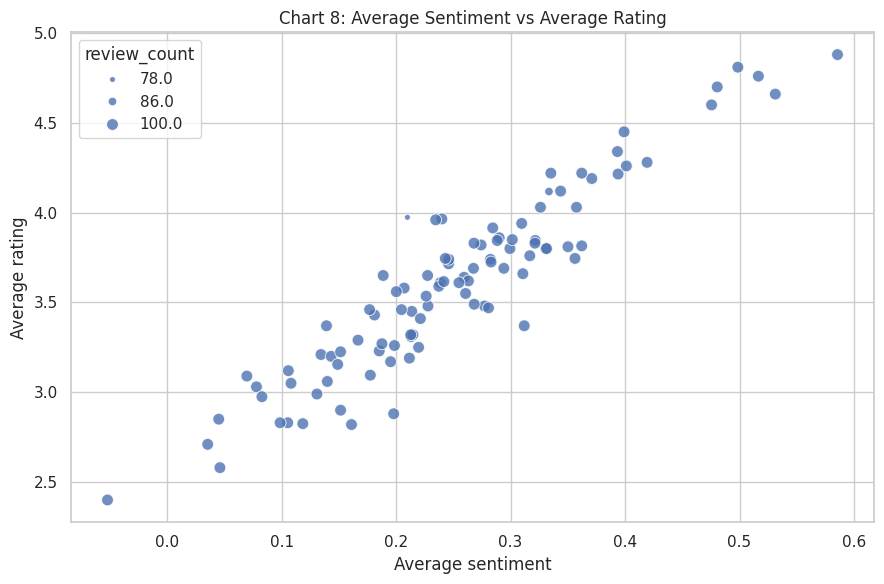

In [22]:
# Chart - 8 visualization code: Sentiment vs Rating
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=model_data,
    x="avg_sentiment",
    y="avg_rating",
    size="review_count",
    alpha=0.8,
    color="C0"
)
plt.title("Chart 8: Average Sentiment vs Average Rating")
plt.xlabel("Average sentiment")
plt.ylabel("Average rating")
plt.tight_layout()
plt.show()

**Why I used it:** I compared average sentiment with average rating to see whether the written reviews tell a similar story to the star ratings.

**What I noticed:** The two measures generally move in the same direction, but there are also restaurants where they do not match perfectly.

**Why it matters:** Those mismatches are useful cases to investigate more closely.

#### Chart - 9

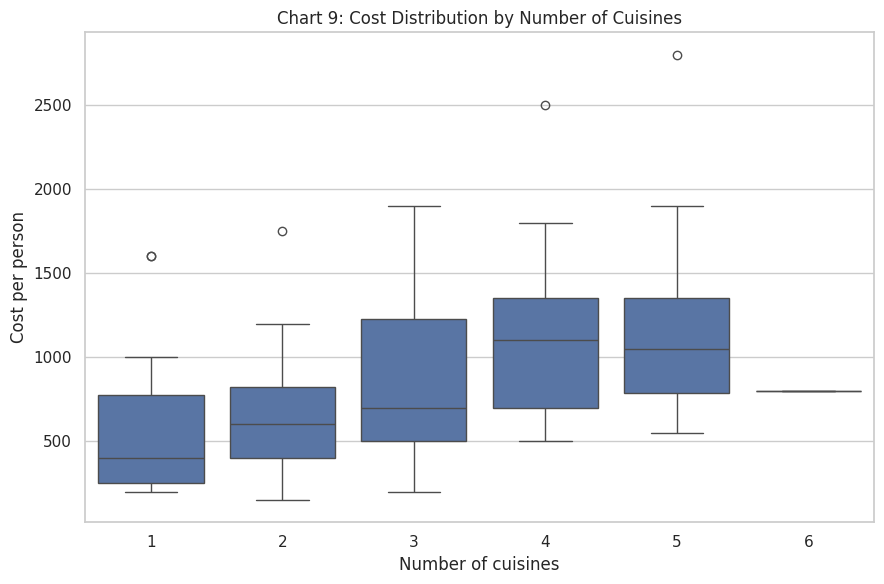

In [23]:
# Chart - 9 visualization code: Cost by Cuisine Breadth
plt.figure(figsize=(9, 6))
sns.boxplot(data=model_data, x="cuisine_count", y="Cost_num", color="C0")
plt.title("Chart 9: Cost Distribution by Number of Cuisines")
plt.xlabel("Number of cuisines")
plt.ylabel("Cost per person")
plt.tight_layout()
plt.show()

**Why I used it:** A box plot lets me compare the price spread for restaurants offering different numbers of cuisines.

**What I noticed:** Restaurants with different cuisine breadths can have noticeably different price ranges.

**Why it matters:** This can help when looking at multi-cuisine positioning and pricing.

#### Chart - 10

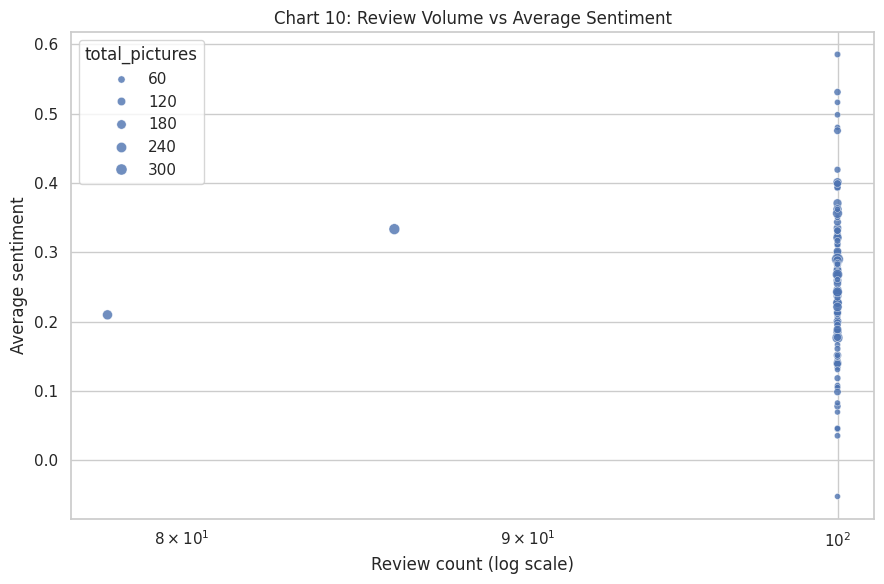

In [24]:
# Chart - 10 visualization code: Review Volume vs Sentiment
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=model_data,
    x="review_count",
    y="avg_sentiment",
    size="total_pictures",
    alpha=0.8
)
plt.xscale("log")
plt.title("Chart 10: Review Volume vs Average Sentiment")
plt.xlabel("Review count (log scale)")
plt.ylabel("Average sentiment")
plt.tight_layout()
plt.show()

**Why I used it:** Review counts are very skewed, so I used a log scale in the scatter plot.

**What I noticed:** A restaurant can be very popular without necessarily having the strongest sentiment.

**Why it matters:** Popularity and customer satisfaction should be treated as separate signals when making recommendations.

#### Chart - 11

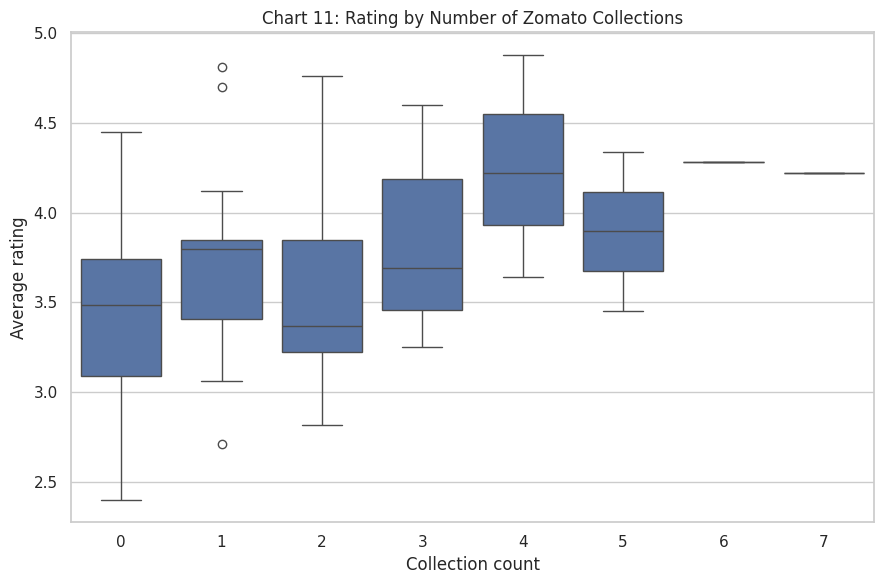

In [25]:
# Chart - 11 visualization code: Collections vs Rating
plt.figure(figsize=(9, 6))
sns.boxplot(data=model_data, x="collection_count", y="avg_rating", color="C0")
plt.title("Chart 11: Rating by Number of Zomato Collections")
plt.xlabel("Collection count")
plt.ylabel("Average rating")
plt.tight_layout()
plt.show()

**Why I used it:** I used a box plot to compare ratings for restaurants with different numbers of collections.

**What I noticed:** The rating distribution changes across collection-count groups.

**Why it matters:** The result can help understand whether curated collection placement is associated with customer quality signals.

#### Chart - 12

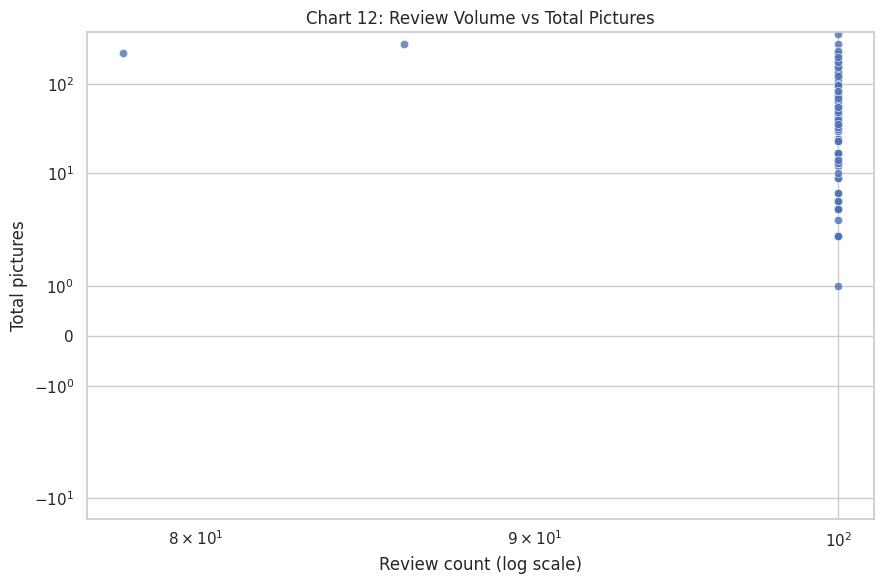

In [26]:
# Chart - 12 visualization code: Pictures vs Review Count
plt.figure(figsize=(9, 6))
sns.scatterplot(data=model_data, x="review_count", y="total_pictures", alpha=0.8, color="C0")
plt.xscale("log")
plt.yscale("symlog")
plt.title("Chart 12: Review Volume vs Total Pictures")
plt.xlabel("Review count (log scale)")
plt.ylabel("Total pictures")
plt.tight_layout()
plt.show()

**Why I used it:** Reviews and pictures are both forms of customer engagement, so I wanted to see how they relate.

**What I noticed:** Restaurants with a similar number of reviews can still have very different amounts of picture activity.

**Why it matters:** More visual user-generated content can make a restaurant page more useful during discovery.

#### Chart - 13

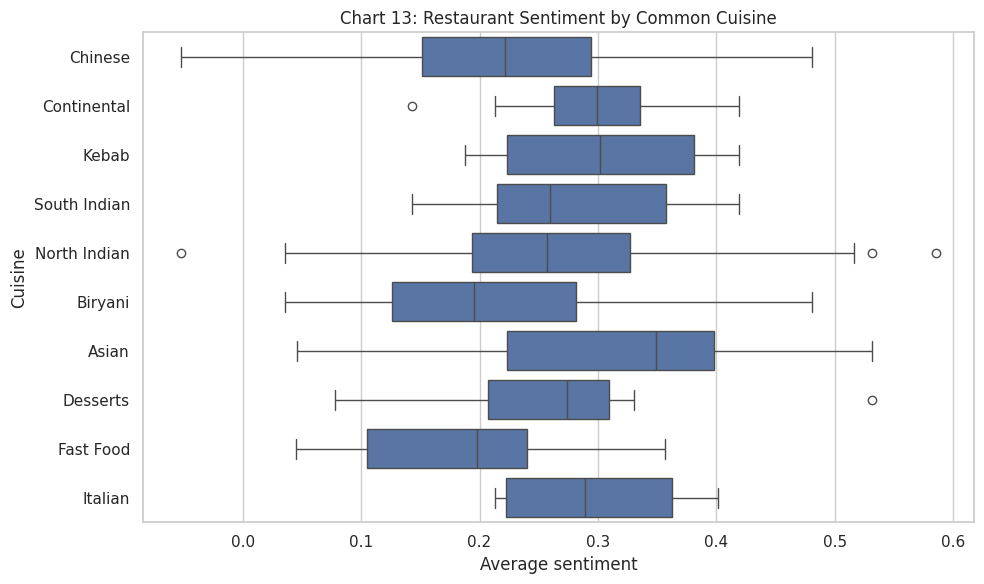

In [27]:
# Chart - 13 visualization code: Sentiment by Cuisine
review_cuisine = model_data[["Name", "Cuisines", "avg_sentiment"]].copy()
review_cuisine["Cuisine"] = review_cuisine["Cuisines"].str.split(",")
review_cuisine = review_cuisine.explode("Cuisine")
review_cuisine["Cuisine"] = review_cuisine["Cuisine"].str.strip()

top_cuisines_for_sentiment = review_cuisine["Cuisine"].value_counts().head(10).index
plot_df = review_cuisine[review_cuisine["Cuisine"].isin(top_cuisines_for_sentiment)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_df, x="avg_sentiment", y="Cuisine", color="C0")
plt.title("Chart 13: Restaurant Sentiment by Common Cuisine")
plt.xlabel("Average sentiment")
plt.ylabel("Cuisine")
plt.tight_layout()
plt.show()

**Why I used it:** A box plot makes it easier to compare sentiment across cuisine groups.

**What I noticed:** Sentiment varies between cuisine categories, although the groups also have a lot of overlap.

**Why it matters:** Cuisine-level sentiment can be useful for category promotions and for finding areas that deserve closer quality checks.

#### Chart - 14 - Correlation Heatmap

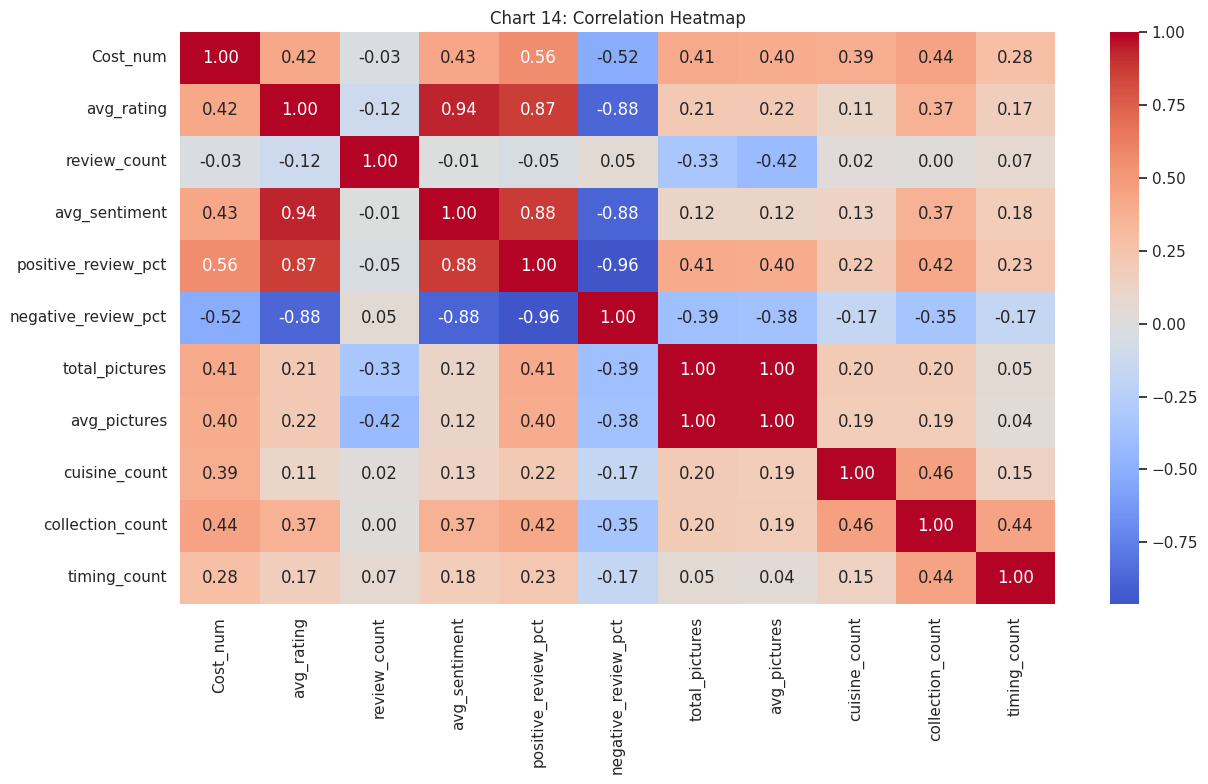

In [28]:
# Chart - 14 visualization code: Correlation Heatmap
corr_cols = [
    "Cost_num", "avg_rating", "review_count", "avg_sentiment",
    "positive_review_pct", "negative_review_pct", "total_pictures",
    "avg_pictures", "cuisine_count", "collection_count", "timing_count"
]

plt.figure(figsize=(13, 8))
sns.heatmap(
    model_data[corr_cols].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Chart 14: Correlation Heatmap")
plt.tight_layout()
plt.show()

**Why I used it:** There are several numerical features, so a heatmap gives a compact view of how they are related.

**What I noticed:** Some variables are strongly related, while others provide more independent information.

**Why it matters:** This helps avoid giving too much weight to duplicate signals before clustering.

#### Chart - 15 - Pair Plot

<Figure size 1200x1200 with 0 Axes>

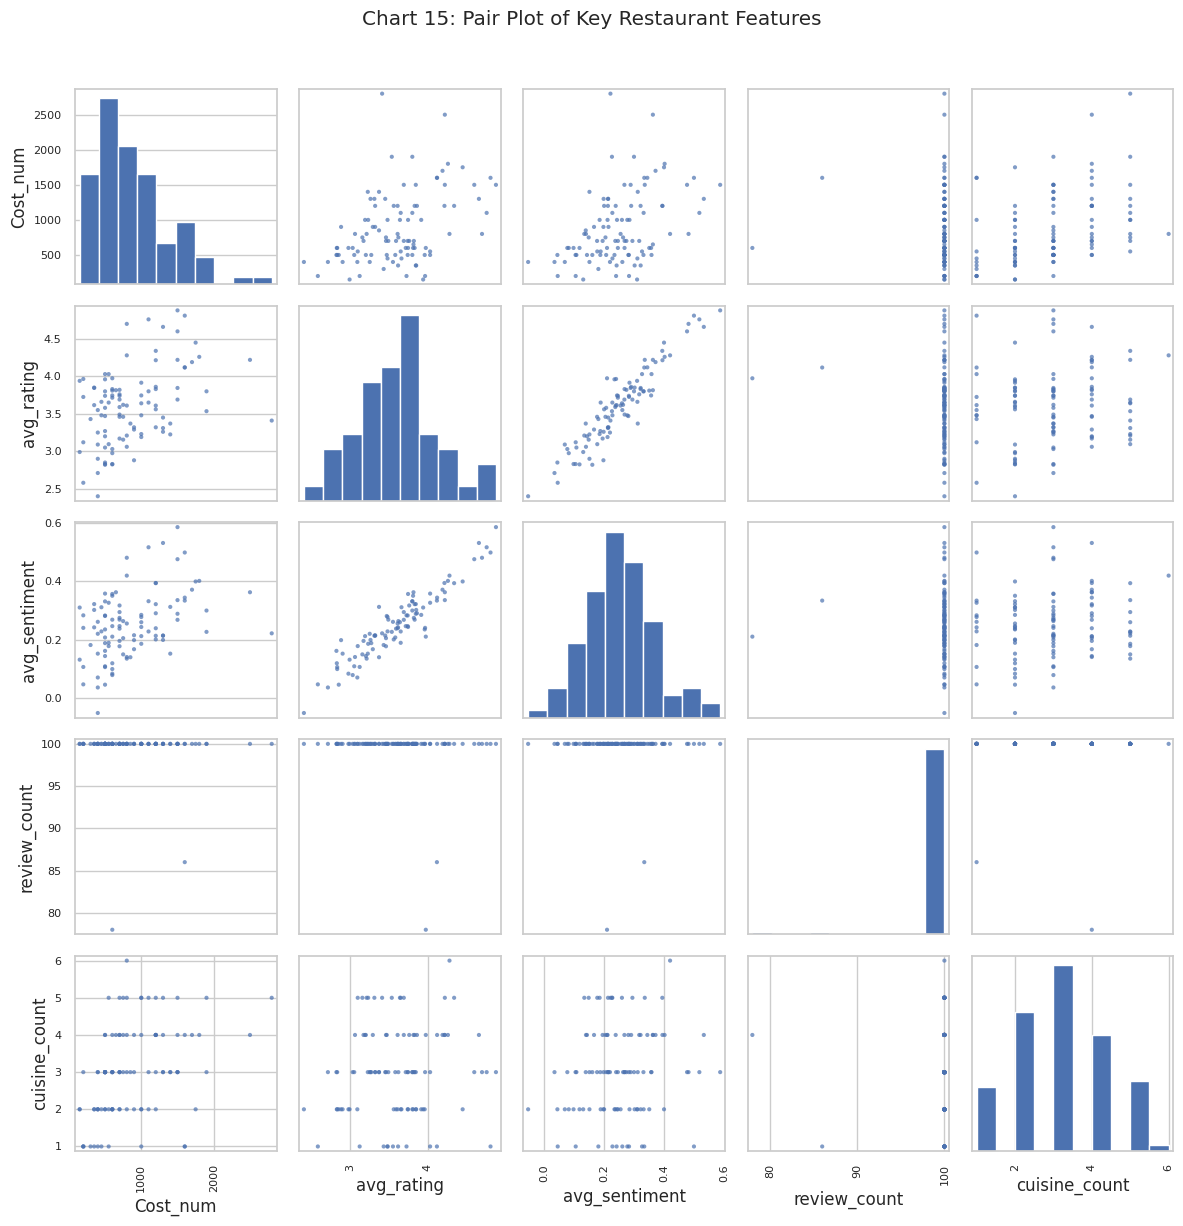

In [29]:
# Chart - 15 visualization code: Pair Plot
pair_cols = ["Cost_num", "avg_rating", "avg_sentiment", "review_count", "cuisine_count"]
pair_sample = model_data[pair_cols].sample(
    n=min(100, len(model_data)),
    random_state=RANDOM_STATE
)

# Matplotlib scatter_matrix provides a deployment-safe pair-plot equivalent.
from pandas.plotting import scatter_matrix
fig = plt.figure(figsize=(12, 12))
axes = scatter_matrix(pair_sample, figsize=(12, 12), diagonal="hist", alpha=0.7)
plt.suptitle("Chart 15: Pair Plot of Key Restaurant Features", y=1.02)
plt.tight_layout()
plt.show()

**Why I used it:** The pair plot lets me look at several important variables together instead of checking them one by one.

**What I noticed:** It helps reveal outliers, relationships and possible groups in the data.

**Why it matters:** These patterns help with feature selection and give an early idea of whether clustering is likely to be useful.

## 5. Hypothesis Testing

### Based on your chart experiments, define three hypothetical statements from the dataset.

I selected the following three questions from the patterns seen during EDA:

1. Is restaurant cost related to average rating?
2. Do high-cost and low-cost restaurants have different customer sentiment?
3. Is review volume related to average rating?

These are tested statistically in the next sections.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** Restaurant cost and average rating have no monotonic association.

**H1:** Restaurant cost and average rating have a monotonic association.

In [30]:
# Perform Statistical Test to obtain P-Value
rho_1, p_1 = stats.spearmanr(
    model_data["Cost_num"],
    model_data["avg_rating"],
    nan_policy="omit"
)

print(f"Spearman correlation = {rho_1:.4f}")
print(f"P-value = {p_1:.6f}")
print("Decision:", "Reject H0" if p_1 < 0.05 else "Fail to reject H0")

Spearman correlation = 0.3826
P-value = 0.000085
Decision: Reject H0


**Which statistical test?** Spearman rank correlation.

**Why?** Both variables are numerical, but normality cannot be assumed and cost is skewed. Spearman correlation measures monotonic association without requiring normally distributed variables.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** High-cost and low-cost restaurants have the same sentiment distribution.

**H1:** High-cost and low-cost restaurants have different sentiment distributions.

In [31]:
# Split restaurants around the median cost and compare sentiment.
median_cost = model_data["Cost_num"].median()

low_cost_sentiment = model_data.loc[
    model_data["Cost_num"] <= median_cost, "avg_sentiment"
].dropna()

high_cost_sentiment = model_data.loc[
    model_data["Cost_num"] > median_cost, "avg_sentiment"
].dropna()

u_2, p_2 = stats.mannwhitneyu(
    low_cost_sentiment,
    high_cost_sentiment,
    alternative="two-sided"
)

print(f"Mann-Whitney U statistic = {u_2:.4f}")
print(f"P-value = {p_2:.6f}")
print("Decision:", "Reject H0" if p_2 < 0.05 else "Fail to reject H0")

Mann-Whitney U statistic = 795.0000
P-value = 0.001746
Decision: Reject H0


**Which statistical test?** Mann-Whitney U test.

**Why?** The two groups are independent and sentiment does not need to follow a normal distribution. The test compares the distributions of the two groups.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** Review volume and average rating have no monotonic association.

**H1:** Review volume and average rating have a monotonic association.

In [32]:
# Perform Spearman correlation between review volume and rating.
rho_3, p_3 = stats.spearmanr(
    model_data["review_count"],
    model_data["avg_rating"],
    nan_policy="omit"
)

print(f"Spearman correlation = {rho_3:.4f}")
print(f"P-value = {p_3:.6f}")
print("Decision:", "Reject H0" if p_3 < 0.05 else "Fail to reject H0")

Spearman correlation = -0.1632
P-value = 0.104632
Decision: Fail to reject H0


**Which statistical test?** Spearman rank correlation.

**Why?** Review count is highly skewed and may contain extreme values. Spearman correlation is more appropriate than Pearson when a monotonic relationship is the research question and normality is uncertain.

## 6. Feature Engineering & Data Pre-processing

### 1. Handling Missing Values

In [33]:
# Review-level numeric/text missing-value handling.
reviews["Review"] = reviews["Review"].fillna("")
reviews["Rating_num"] = pd.to_numeric(reviews["Rating"], errors="coerce")

# For restaurant-level model features, missing review aggregates are set to zero only
# for fields where zero means no observed review evidence. These restaurants are then
# excluded from clustering, so they do not receive artificial customer sentiment.
model_data = data[data["review_count"].fillna(0) > 0].copy()

numeric_model_cols = [
    "Cost_num", "avg_rating", "review_count", "avg_sentiment",
    "positive_review_pct", "negative_review_pct",
    "total_pictures", "avg_pictures",
    "cuisine_count", "collection_count", "timing_count"
]

for col in numeric_model_cols:
    model_data[col] = pd.to_numeric(model_data[col], errors="coerce")

# Median imputation for any remaining numerical missing values.
for col in numeric_model_cols:
    model_data[col] = model_data[col].fillna(model_data[col].median())

**Missing-value approach:** I used median values for remaining numerical features and empty strings for missing text fields.

**Why?** Median is safer than mean when a variable has a few unusually large values. For restaurants that have no reviews, I did not create fake review statistics. They are left out of the review-dependent clustering step.

### 2. Handling Outliers

In [34]:
# Detect and cap extreme numerical values using the IQR method.
def iqr_cap(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series.clip(lower, upper), lower, upper

outlier_report = []

outlier_cols = [
    "Cost_num", "review_count", "total_pictures", "avg_pictures",
    "cuisine_count", "collection_count", "timing_count"
]

for col in outlier_cols:
    capped, lower, upper = iqr_cap(model_data[col])
    count = ((model_data[col] < lower) | (model_data[col] > upper)).sum()
    model_data[col] = capped
    outlier_report.append([col, lower, upper, int(count)])

display(pd.DataFrame(
    outlier_report,
    columns=["Feature", "Lower_Bound", "Upper_Bound", "Outlier_Count"]
))

,Feature,Lower_Bound,Upper_Bound,Outlier_Count
0,Cost_num,-550.000,2250.000,2
1,review_count,100.000,100.000,2
2,total_pictures,-127.000,257.000,3
3,avg_pictures,-1.270,2.570,4
4,cuisine_count,-1.000,7.000,0
5,collection_count,-1.875,3.125,7
6,timing_count,-0.500,3.500,9


**Outlier approach:** I used IQR-based capping for highly skewed numerical engagement variables.

I did not simply delete large review or picture counts because they can be real and useful business information. Capping only reduces their influence on distance-based clustering.

### 3. Categorical Encoding

In [35]:
# Multi-label categorical encoding for the most common cuisines and collections.
# This satisfies the categorical-encoding requirement while keeping the feature space manageable.

def split_labels(text):
    return [item.strip() for item in str(text).split(",") if item.strip()]

cuisine_lists = model_data["Cuisines"].apply(split_labels)
collection_lists = model_data["Collections"].apply(split_labels)

top_10_cuisines = (
    cuisine_lists.explode().value_counts().head(10).index.tolist()
)
top_10_collections = (
    collection_lists.explode().value_counts().head(10).index.tolist()
)

def top_label_flags(series, top_labels, prefix):
    return pd.DataFrame({
        f"{prefix}_{label}": series.apply(lambda items: int(label in items))
        for label in top_labels
    }, index=series.index)

cuisine_flags = top_label_flags(cuisine_lists, top_10_cuisines, "Cuisine")
collection_flags = top_label_flags(collection_lists, top_10_collections, "Collection")

model_data = pd.concat([model_data, cuisine_flags, collection_flags], axis=1)

print("Encoded cuisine columns:", cuisine_flags.columns.tolist())
print("Encoded collection columns:", collection_flags.columns.tolist())

Encoded cuisine columns: ['Cuisine_North Indian', 'Cuisine_Chinese', 'Cuisine_Continental', 'Cuisine_Biryani', 'Cuisine_Asian', 'Cuisine_Italian', 'Cuisine_Fast Food', 'Cuisine_Desserts', 'Cuisine_South Indian', 'Cuisine_Kebab']
Encoded collection columns: ['Collection_Great Buffets', 'Collection_Food Hygiene Rated Restaurants in Hyderabad', 'Collection_Live Sports Screenings', "Collection_Hyderabad's Hottest", 'Collection_Corporate Favorites', 'Collection_Gold Curated', 'Collection_Top-Rated', 'Collection_Trending This Week', 'Collection_Best Bars & Pubs', 'Collection_Sunday Brunches']


**Encoding approach:** I used multi-label binary encoding for fields such as cuisines and collections.

A restaurant can belong to more than one cuisine or collection, so treating these as a single category would lose information. Binary indicators keep the useful presence/absence information.

### 4. Textual Data Preprocessing

#### 1. Expand Contraction

In [36]:
# Expand common English contractions.
reviews["Review_expanded"] = reviews["Review"].apply(expand_contractions)
display(reviews[["Review", "Review_expanded"]].head(3))

,Review,Review_expanded
0,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate ...","The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate ..."
1,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soume...,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soume...
2,A must try.. great food great ambience. Thnx for the service by Pradeep and Subroto. My personal recommendation is P...,A must try.. great food great ambience. Thnx for the service by Pradeep and Subroto. My personal recommendation is P...


#### 2. Lower Casing

In [37]:
# Convert text to lowercase.
reviews["Review_lower"] = reviews["Review_expanded"].str.lower()
display(reviews["Review_lower"].head(3))

,Review_lower
0,"the ambience was good, food was quite good . had saturday lunch , which was cost effective .\ngood place for a sate ..."
1,ambience is too good for a pleasant evening. service is very prompt. food is good. over all a good experience. soume...
2,a must try.. great food great ambience. thnx for the service by pradeep and subroto. my personal recommendation is p...


#### 3. Removing Punctuations

In [38]:
# Remove punctuation characters.
reviews["Review_no_punct"] = reviews["Review_lower"].apply(
    lambda x: re.sub(r"[^a-z\s]", " ", str(x))
)
reviews["Review_no_punct"] = reviews["Review_no_punct"].str.replace(
    r"\s+", " ", regex=True
).str.strip()

display(reviews["Review_no_punct"].head(3))

,Review_no_punct
0,the ambience was good food was quite good had saturday lunch which was cost effective good place for a sate brunch o...
1,ambience is too good for a pleasant evening service is very prompt food is good over all a good experience soumen da...
2,a must try great food great ambience thnx for the service by pradeep and subroto my personal recommendation is penne...


#### 4. Removing URLs & Removing words and digits contain digits.

In [39]:
# Remove URLs and tokens containing digits.
def remove_urls_and_digit_words(text):
    text = re.sub(r"http\S+|www\.\S+", " ", str(text))
    text = re.sub(r"\b\w*\d\w*\b", " ", text)
    return re.sub(r"\s+", " ", text).strip()

reviews["Review_no_urls_digits"] = reviews["Review_no_punct"].apply(
    remove_urls_and_digit_words
)
display(reviews["Review_no_urls_digits"].head(3))

,Review_no_urls_digits
0,the ambience was good food was quite good had saturday lunch which was cost effective good place for a sate brunch o...
1,ambience is too good for a pleasant evening service is very prompt food is good over all a good experience soumen da...
2,a must try great food great ambience thnx for the service by pradeep and subroto my personal recommendation is penne...


#### 5. Removing Stopwords & Removing White spaces

In [40]:
# Remove common stopwords.
reviews["Review_no_stopwords"] = reviews["Review_no_urls_digits"].apply(
    lambda x: " ".join(
        word for word in str(x).split() if word not in STOPWORDS
    )
)

# Remove extra whitespace.
reviews["Review_clean"] = reviews["Review_no_stopwords"].str.replace(
    r"\s+", " ", regex=True
).str.strip()

display(reviews[["Review_no_stopwords", "Review_clean"]].head(3))

,Review_no_stopwords,Review_clean
0,ambience good food quite good saturday lunch which cost effective good place sate brunch one can also chill friends ...,ambience good food quite good saturday lunch which cost effective good place sate brunch one can also chill friends ...
1,ambience good pleasant evening service prompt food good over all good experience soumen das kudos service,ambience good pleasant evening service prompt food good over all good experience soumen das kudos service
2,must try great food great ambience thnx service pradeep subroto personal recommendation penne alfredo pasta also mus...,must try great food great ambience thnx service pradeep subroto personal recommendation penne alfredo pasta also mus...


#### 6. Rephrase Text

In [41]:
# Rephrase is represented by contraction expansion and normalization rather than
# changing the customer's original meaning.
reviews["Review_rephrased"] = reviews["Review_clean"]
display(reviews["Review_rephrased"].head(3))

,Review_rephrased
0,ambience good food quite good saturday lunch which cost effective good place sate brunch one can also chill friends ...
1,ambience good pleasant evening service prompt food good over all good experience soumen das kudos service
2,must try great food great ambience thnx service pradeep subroto personal recommendation penne alfredo pasta also mus...


#### 7. Tokenization

In [42]:
# Tokenize the cleaned review text using whitespace tokens.
reviews["tokens"] = reviews["Review_clean"].apply(
    lambda x: str(x).split()
)
display(reviews[["Review_clean", "tokens"]].head(3))

,Review_clean,tokens
0,ambience good food quite good saturday lunch which cost effective good place sate brunch one can also chill friends ...,"[ambience, good, food, quite, good, saturday, lunch, which, cost, effective, good, place, sate, brunch, one, can, al..."
1,ambience good pleasant evening service prompt food good over all good experience soumen das kudos service,"[ambience, good, pleasant, evening, service, prompt, food, good, over, all, good, experience, soumen, das, kudos, se..."
2,must try great food great ambience thnx service pradeep subroto personal recommendation penne alfredo pasta also mus...,"[must, try, great, food, great, ambience, thnx, service, pradeep, subroto, personal, recommendation, penne, alfredo,..."


#### 8. Text Normalization

In [43]:
# Lightweight stemming rule for reproducibility without downloading external NLP corpora.
def simple_stem(word):
    for suffix in ("ingly", "edly", "ing", "ed", "ly", "es", "s"):
        if len(word) > len(suffix) + 2 and word.endswith(suffix):
            return word[:-len(suffix)]
    return word

reviews["stemmed_tokens"] = reviews["tokens"].apply(
    lambda tokens: [simple_stem(token) for token in tokens]
)

display(reviews[["tokens", "stemmed_tokens"]].head(3))

,tokens,stemmed_tokens
0,"[ambience, good, food, quite, good, saturday, lunch, which, cost, effective, good, place, sate, brunch, one, can, al...","[ambience, good, food, quite, good, saturday, lunch, which, cost, effective, good, place, sate, brunch, one, can, al..."
1,"[ambience, good, pleasant, evening, service, prompt, food, good, over, all, good, experience, soumen, das, kudos, se...","[ambience, good, pleasant, even, service, prompt, food, good, over, all, good, experience, soumen, das, kudo, service]"
2,"[must, try, great, food, great, ambience, thnx, service, pradeep, subroto, personal, recommendation, penne, alfredo,...","[must, try, great, food, great, ambience, thnx, service, pradeep, subroto, personal, recommendation, penne, alfredo,..."


**Text normalization:** I used a lightweight suffix-based stemming step.

I chose this simple approach because it is enough for this project and keeps the notebook easy to run without downloading extra language resources.

#### 9. Part of speech tagging

In [44]:
# POS tagging is optional for this business problem. We use a lightweight deterministic
# heuristic rather than a downloaded NLP model, so the notebook remains deployment-safe.

def simple_pos_tag(tokens):
    tags = []
    for token in tokens:
        if token.endswith("ly"):
            tag = "ADV"
        elif token.endswith(("ing", "ed")):
            tag = "VERB"
        elif token.endswith(("ous", "ful", "able", "ive", "al")):
            tag = "ADJ"
        else:
            tag = "OTHER"
        tags.append((token, tag))
    return tags

reviews["pos_tags"] = reviews["stemmed_tokens"].apply(simple_pos_tag)
display(reviews[["stemmed_tokens", "pos_tags"]].head(3))

,stemmed_tokens,pos_tags
0,"[ambience, good, food, quite, good, saturday, lunch, which, cost, effective, good, place, sate, brunch, one, can, al...","[(ambience, OTHER), (good, OTHER), (food, OTHER), (quite, OTHER), (good, OTHER), (saturday, OTHER), (lunch, OTHER), ..."
1,"[ambience, good, pleasant, even, service, prompt, food, good, over, all, good, experience, soumen, das, kudo, service]","[(ambience, OTHER), (good, OTHER), (pleasant, OTHER), (even, OTHER), (service, OTHER), (prompt, OTHER), (food, OTHER..."
2,"[must, try, great, food, great, ambience, thnx, service, pradeep, subroto, personal, recommendation, penne, alfredo,...","[(must, OTHER), (try, OTHER), (great, OTHER), (food, OTHER), (great, OTHER), (ambience, OTHER), (thnx, OTHER), (serv..."


#### 10. Text Vectorization

In [45]:
# TF-IDF converts customer-review text into numerical vectors.
tfidf = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

tfidf_matrix = tfidf.fit_transform(reviews["Review_clean"].fillna(""))

print("TF-IDF matrix shape:", tfidf_matrix.shape)

# Display the most frequent TF-IDF vocabulary terms.
tfidf_feature_names = np.array(tfidf.get_feature_names_out())
term_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
top_terms = pd.DataFrame({
    "Term": tfidf_feature_names,
    "Mean_TFIDF": term_scores
}).sort_values("Mean_TFIDF", ascending=False).head(20)

display(top_terms)

TF-IDF matrix shape: (9964, 1000)


,Term,Mean_TFIDF
337,good,0.092594
287,food,0.052453
652,place,0.044243
770,service,0.033760
126,chicken,0.029727
854,taste,0.026867
564,nice,0.026520
352,great,0.025335
30,ambience,0.023143
601,ordered,0.022872


**Vectorization:** I used TF-IDF with unigrams and bigrams.

TF-IDF is useful here because it gives more weight to words that are informative in the review set and less weight to very common words. The text vectors are used for the NLP part, while the main restaurant clustering uses the more interpretable restaurant-level features.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [46]:
# Add log-transformed versions of highly skewed engagement variables.
model_data["log_review_count"] = np.log1p(model_data["review_count"])
model_data["log_total_pictures"] = np.log1p(model_data["total_pictures"])

# Remove raw skewed versions from the final clustering matrix in favor of log versions.
print("Created log_review_count and log_total_pictures.")

Created log_review_count and log_total_pictures.


#### 2. Feature Selection

In [47]:
# Select interpretable business features for clustering.
base_cluster_features = [
    "Cost_num",
    "avg_rating",
    "log_review_count",
    "avg_sentiment",
    "positive_review_pct",
    "negative_review_pct",
    "log_total_pictures",
    "avg_pictures",
    "cuisine_count",
    "collection_count",
    "timing_count"
]

# Add the top cuisine/collection binary flags.
encoded_features = list(cuisine_flags.columns) + list(collection_flags.columns)

cluster_features = base_cluster_features + encoded_features
X_raw = model_data[cluster_features].replace([np.inf, -np.inf], np.nan)

# Final safety fill.
X_raw = X_raw.fillna(X_raw.median(numeric_only=True)).fillna(0)

print("Number of final clustering features:", len(cluster_features))
display(X_raw.head())

Number of final clustering features: 31


,Cost_num,avg_rating,log_review_count,avg_sentiment,positive_review_pct,negative_review_pct,log_total_pictures,avg_pictures,cuisine_count,collection_count,timing_count,Cuisine_North Indian,Cuisine_Chinese,Cuisine_Continental,Cuisine_Biryani,Cuisine_Asian,Cuisine_Italian,Cuisine_Fast Food,Cuisine_Desserts,Cuisine_South Indian,Cuisine_Kebab,Collection_Great Buffets,Collection_Food Hygiene Rated Restaurants in Hyderabad,Collection_Live Sports Screenings,Collection_Hyderabad's Hottest,Collection_Corporate Favorites,Collection_Gold Curated,Collection_Top-Rated,Collection_Trending This Week,Collection_Best Bars & Pubs,Collection_Sunday Brunches
0,800.0,4.28,4.615121,0.419231,87.0,9.0,3.688879,0.39,6,3.125,2.0,1,1,1,0,0,0,0,0,1,1,1,1,1,0,1,1,1,0,0,0
1,800.0,4.70,4.615121,0.480494,93.0,4.0,1.098612,0.02,3,1.000,1.0,1,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,1300.0,4.66,4.615121,0.531244,98.0,2.0,4.025352,0.55,4,2.000,2.0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0
3,800.0,3.21,4.615121,0.134391,65.0,24.0,3.433987,0.30,5,1.000,1.0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1200.0,4.34,4.615121,0.393337,91.0,8.0,3.806662,0.44,5,3.125,3.5,1,1,1,0,1,0,0,0,0,0,0,1,0,1,0,1,1,0,1,0


**Feature selection methods:** business relevance, correlation inspection, removal of redundant raw skewed variables, and dimensionality control through top-category encoding.

**Important features:** cost, rating, sentiment, review engagement, picture engagement, cuisine breadth and collection presence because they directly describe restaurant price, quality, customer experience and popularity.

### 5. Data Transformation

Yes. Review count and picture count are strongly right-skewed. I used `log1p` for these engagement variables because it reduces the effect of very large values without losing the zero values.

In [48]:
# Data transformation
X_transformed = X_raw.copy()
print("Log-transformed engagement features are included in X_transformed.")

Log-transformed engagement features are included in X_transformed.


### 6. Data Scaling

In [49]:
# Standardize all clustering features because clustering is distance-sensitive.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_transformed)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (100, 31)


**Scaling method:** StandardScaler.

**Why:** Features have different units and ranges. Standardization gives each feature a comparable scale before distance-based clustering.

### 7. Dimesionality Reduction

PCA is useful here mainly for **visualization**. The clustering feature set has several variables, so reducing it to two dimensions makes the final clusters easier to plot. I did not use only the PCA components for the final clustering because that could throw away useful information.

In [50]:
# PCA only for visualization.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained by 2 components:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.23190823 0.11182408]
Total variance explained by 2 components: 0.343732310724184


**Technique:** Principal Component Analysis (PCA).

**Why:** It compresses the standardized feature space into two components for visualization while the final model continues to use the full feature set.

### 8. Data Splitting

In [51]:
# In unsupervised learning there is no target variable, so a conventional stratified
# train/test split is not appropriate. We create reproducible folds for model stability
# and parameter comparison instead.
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
folds = list(kf.split(X_scaled))

print("Created", len(folds), "folds for unsupervised validation/stability analysis.")

Created 5 folds for unsupervised validation/stability analysis.


I used five-fold stability evaluation instead of a normal supervised train/test split. There is no target label in this project, so accuracy on a test set would not make sense. The five folds give a consistent way to compare different clustering settings.

### 9. Handling Imbalanced Dataset

This is an unsupervised problem, so class imbalance is not directly applicable. After clustering, I still check the size of each cluster. A very small cluster may be an interesting niche group, but it could also mean that the model has separated a few unusual restaurants.

In [52]:
# Cluster balance will be checked after model fitting.
print("Class imbalance handling is not required because there is no supervised target.")

Class imbalance handling is not required because there is no supervised target.


## 7. ML Model Implementation

### ML Model - 1: K-Means

In [53]:
# -----------------------------
# ML Model - 1: K-Means
# -----------------------------
# Evaluate candidate values of k using internal clustering metrics.
k_results = []

for k in range(2, 9):
    kmeans_model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE
    )
    labels = kmeans_model.fit_predict(X_scaled)

    k_results.append({
        "k": k,
        "Silhouette": silhouette_score(X_scaled, labels),
        "Davies_Bouldin": davies_bouldin_score(X_scaled, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X_scaled, labels),
        "Inertia": kmeans_model.inertia_
    })

k_results_df = pd.DataFrame(k_results)
display(k_results_df)

,k,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inertia
0,2,0.234282,2.219376,18.472967,2524.190879
1,3,0.223267,2.036882,15.059398,2289.197259
2,4,0.106358,2.075277,13.932269,2090.033905
3,5,0.106601,2.028212,12.341443,1974.152136
4,6,0.130604,1.721781,12.344217,1810.930127
5,7,0.109313,1.801088,11.477650,1723.649003
6,8,0.130856,1.694719,11.511867,1599.229894


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

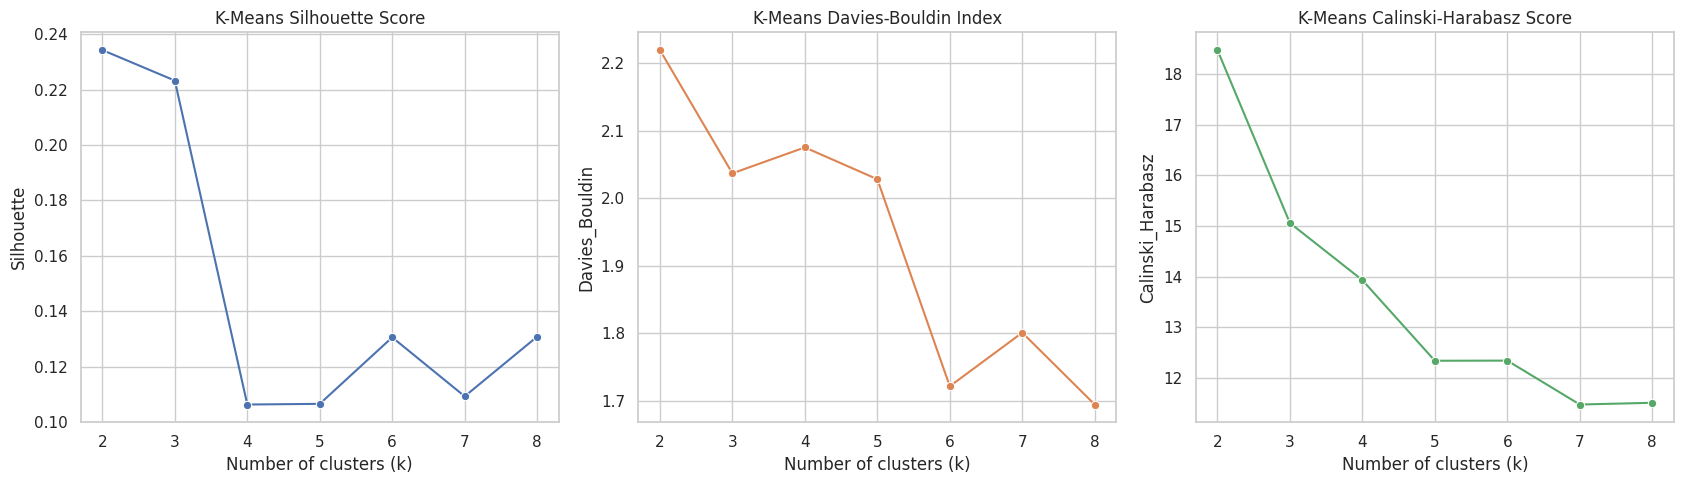

In [54]:
# Visualizing evaluation metric score chart for K-Means.
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.lineplot(data=k_results_df, x="k", y="Silhouette", marker="o", color="C0", ax=axes[0])
axes[0].set_title("K-Means Silhouette Score")
axes[0].set_xlabel("Number of clusters (k)")

sns.lineplot(data=k_results_df, x="k", y="Davies_Bouldin", marker="o", color="C1", ax=axes[1])
axes[1].set_title("K-Means Davies-Bouldin Index")
axes[1].set_xlabel("Number of clusters (k)")

sns.lineplot(data=k_results_df, x="k", y="Calinski_Harabasz", marker="o", color="C2", ax=axes[2])
axes[2].set_title("K-Means Calinski-Harabasz Score")
axes[2].set_xlabel("Number of clusters (k)")

plt.tight_layout()
plt.show()

**Model explanation:** K-Means divides the restaurants into `k` groups by keeping similar observations close to the same cluster.

For evaluation, I use three internal metrics:
- **Silhouette Score:** higher is better.
- **Davies-Bouldin Index:** lower is better.
- **Calinski-Harabasz Score:** higher is better.

I look at all three rather than relying on just one number.

#### 2. Cross- Validation & Hyperparameter Tuning

In [55]:
# Unsupervised cross-validation/stability helper.
def unsupervised_cv_score(estimator_builder, X, n_splits=5):
    scores = []
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    for train_idx, _ in kfold.split(X):
        X_train = X[train_idx]
        model = estimator_builder()
        labels = model.fit_predict(X_train)

        if len(np.unique(labels)) < 2:
            scores.append(np.nan)
        else:
            scores.append(silhouette_score(X_train, labels))

    return float(np.nanmean(scores))

# Grid-style parameter search for K-Means.
kmeans_grid_results = []

for params in ParameterGrid({
    "n_clusters": list(range(2, 9)),
    "n_init": [10, 20, 30]
}):
    def builder(params=params):
        return KMeans(
            n_clusters=params["n_clusters"],
            n_init=params["n_init"],
            random_state=RANDOM_STATE
        )

    cv_score = unsupervised_cv_score(builder, X_scaled, n_splits=5)
    kmeans_grid_results.append({**params, "CV_Silhouette": cv_score})

kmeans_grid_df = pd.DataFrame(kmeans_grid_results).sort_values(
    "CV_Silhouette", ascending=False
)

display(kmeans_grid_df.head(10))

best_kmeans_params = kmeans_grid_df.iloc[0].to_dict()
best_k = int(best_kmeans_params["n_clusters"])
best_n_init = int(best_kmeans_params["n_init"])

kmeans_final = KMeans(
    n_clusters=best_k,
    n_init=best_n_init,
    random_state=RANDOM_STATE
)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

kmeans_final_metrics = {
    "Silhouette": silhouette_score(X_scaled, kmeans_labels),
    "Davies_Bouldin": davies_bouldin_score(X_scaled, kmeans_labels),
    "Calinski_Harabasz": calinski_harabasz_score(X_scaled, kmeans_labels)
}

print("Best K-Means parameters:", best_k, best_n_init)
print("Final K-Means metrics:", kmeans_final_metrics)

,n_clusters,n_init,CV_Silhouette
0,2,10,0.259019
1,2,20,0.253127
2,2,30,0.253127
5,3,30,0.154164
4,3,20,0.153961
18,8,10,0.134790
19,8,20,0.134473
20,8,30,0.132919
15,7,10,0.126563
3,3,10,0.126315


Best K-Means parameters: 2 10
Final K-Means metrics: {'Silhouette': np.float64(0.2342821261003514), 'Davies_Bouldin': np.float64(2.2193755739244168), 'Calinski_Harabasz': np.float64(18.472966626689814)}


**Tuning method:** I used a grid-style search over the main K-Means settings and evaluated the candidates with five-fold unsupervised stability scoring.

The most important choice is the number of clusters. Testing several values is better than choosing `k` just because it is common.

### ML Model - 2: Agglomerative Clustering

In [56]:
# -----------------------------
# ML Model - 2: Agglomerative Clustering
# -----------------------------
agglo_results = []

for linkage in ["ward", "complete", "average"]:
    # Ward linkage requires Euclidean distance and is supported directly.
    for n_clusters in range(2, 9):
        if linkage == "ward":
            model = AgglomerativeClustering(
                n_clusters=n_clusters,
                linkage=linkage
            )
        else:
            model = AgglomerativeClustering(
                n_clusters=n_clusters,
                linkage=linkage
            )

        labels = model.fit_predict(X_scaled)

        agglo_results.append({
            "linkage": linkage,
            "n_clusters": n_clusters,
            "Silhouette": silhouette_score(X_scaled, labels),
            "Davies_Bouldin": davies_bouldin_score(X_scaled, labels),
            "Calinski_Harabasz": calinski_harabasz_score(X_scaled, labels)
        })

agglo_results_df = pd.DataFrame(agglo_results)
display(
    agglo_results_df.sort_values("Silhouette", ascending=False).head(10)
)

best_agglo_row = agglo_results_df.sort_values(
    "Silhouette", ascending=False
).iloc[0]

best_agglo = AgglomerativeClustering(
    n_clusters=int(best_agglo_row["n_clusters"]),
    linkage=best_agglo_row["linkage"]
)
agglo_labels = best_agglo.fit_predict(X_scaled)

agglo_metrics = {
    "Silhouette": silhouette_score(X_scaled, agglo_labels),
    "Davies_Bouldin": davies_bouldin_score(X_scaled, agglo_labels),
    "Calinski_Harabasz": calinski_harabasz_score(X_scaled, agglo_labels)
}

print("Best Agglomerative configuration:", best_agglo_row.to_dict())
print("Agglomerative metrics:", agglo_metrics)

,linkage,n_clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz
14,average,2,0.437746,1.074461,10.813124
15,average,3,0.422217,0.752568,6.660614
7,complete,2,0.387441,1.306468,12.657670
8,complete,3,0.336291,1.238296,9.099028
16,average,4,0.328483,0.916643,6.278944
17,average,5,0.281513,0.929539,6.075245
0,ward,2,0.267783,2.276542,16.531378
18,average,6,0.258590,0.867119,5.468382
19,average,7,0.256930,0.720435,4.888309
20,average,8,0.256098,0.745302,5.439982


Best Agglomerative configuration: {'linkage': 'average', 'n_clusters': 2, 'Silhouette': 0.4377462062457752, 'Davies_Bouldin': 1.0744608210121827, 'Calinski_Harabasz': 10.813123850721759}
Agglomerative metrics: {'Silhouette': np.float64(0.4377462062457752), 'Davies_Bouldin': np.float64(1.0744608210121827), 'Calinski_Harabasz': np.float64(10.813123850721759)}


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

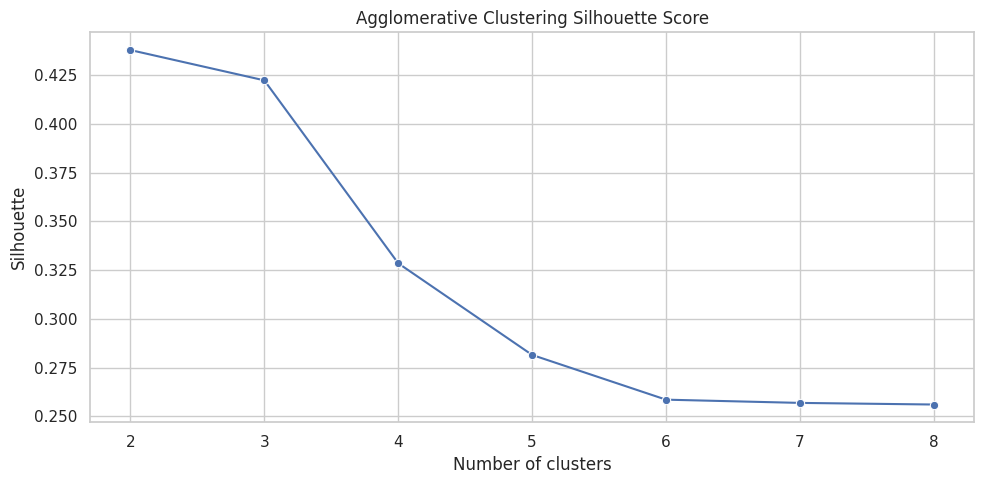

In [57]:
# Visualizing Agglomerative evaluation metrics.
agglo_plot = agglo_results_df[
    agglo_results_df["linkage"] == best_agglo_row["linkage"]
].sort_values("n_clusters")

plt.figure(figsize=(10, 5))
sns.lineplot(data=agglo_plot, x="n_clusters", y="Silhouette", marker="o", color="C0")
plt.title("Agglomerative Clustering Silhouette Score")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.show()

**Model explanation:** Agglomerative clustering starts with individual observations and gradually joins similar observations together.

I compared different linkage choices and cluster counts. This model is useful as a second view of the restaurant groups because it does not build the clusters in exactly the same way as K-Means.

#### 2. Cross- Validation & Hyperparameter Tuning

In [58]:
# Five-fold stability search for Agglomerative Clustering.
agglo_cv_results = []

for params in ParameterGrid({
    "n_clusters": list(range(2, 9)),
    "linkage": ["ward", "complete", "average"]
}):
    def builder(params=params):
        return AgglomerativeClustering(
            n_clusters=params["n_clusters"],
            linkage=params["linkage"]
        )

    cv_score = unsupervised_cv_score(builder, X_scaled, n_splits=5)
    agglo_cv_results.append({**params, "CV_Silhouette": cv_score})

agglo_cv_df = pd.DataFrame(agglo_cv_results).sort_values(
    "CV_Silhouette", ascending=False
)

display(agglo_cv_df.head(10))

,linkage,n_clusters,CV_Silhouette
14,average,2,0.432607
15,average,3,0.381155
7,complete,2,0.372802
16,average,4,0.313342
8,complete,3,0.288572
17,average,5,0.281479
18,average,6,0.265509
20,average,8,0.259963
19,average,7,0.257678
0,ward,2,0.248239


**Tuning method:** I compared several linkage and cluster-count combinations using the same five-fold unsupervised stability idea.

The tuned version is compared with the basic version using the same clustering metrics, so the comparison is fair.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

The three metrics have slightly different meanings:

- **Silhouette:** higher values mean the restaurants are closer to their own group than to other groups. From a business point of view, clearer groups are easier to target.
- **Davies-Bouldin:** lower values mean less overlap between groups. That makes the segment definitions easier to explain.
- **Calinski-Harabasz:** higher values indicate compact and well-separated groups.

Using all three gives a better picture than looking at one metric alone.

### ML Model - 3: Gaussian Mixture Model

In [59]:
# -----------------------------
# ML Model - 3: Gaussian Mixture Model
# -----------------------------
gmm_results = []

for n_components in range(2, 9):
    for covariance_type in ["full", "tied", "diag"]:
        gmm = GaussianMixture(
            n_components=n_components,
            covariance_type=covariance_type,
            random_state=RANDOM_STATE
        )
        labels = gmm.fit_predict(X_scaled)

        if len(np.unique(labels)) < 2:
            continue

        gmm_results.append({
            "n_components": n_components,
            "covariance_type": covariance_type,
            "Silhouette": silhouette_score(X_scaled, labels),
            "Davies_Bouldin": davies_bouldin_score(X_scaled, labels),
            "Calinski_Harabasz": calinski_harabasz_score(X_scaled, labels),
            "BIC": gmm.bic(X_scaled),
            "AIC": gmm.aic(X_scaled)
        })

gmm_results_df = pd.DataFrame(gmm_results)
display(gmm_results_df.sort_values("Silhouette", ascending=False).head(10))

best_gmm_row = gmm_results_df.sort_values("Silhouette", ascending=False).iloc[0]

gmm_final = GaussianMixture(
    n_components=int(best_gmm_row["n_components"]),
    covariance_type=best_gmm_row["covariance_type"],
    random_state=RANDOM_STATE
)
gmm_labels = gmm_final.fit_predict(X_scaled)

gmm_metrics = {
    "Silhouette": silhouette_score(X_scaled, gmm_labels),
    "Davies_Bouldin": davies_bouldin_score(X_scaled, gmm_labels),
    "Calinski_Harabasz": calinski_harabasz_score(X_scaled, gmm_labels)
}

print("Best GMM configuration:", best_gmm_row.to_dict())
print("GMM metrics:", gmm_metrics)

,n_components,covariance_type,Silhouette,Davies_Bouldin,Calinski_Harabasz,BIC,AIC
2,2,diag,0.253249,2.207900,17.660548,-1381.263834,-1706.910107
5,3,diag,0.236373,2.042544,14.194930,-2268.434770,-2758.206765
0,2,full,0.214045,2.375566,16.191504,1082.042432,-1666.412115
3,3,full,0.199113,2.153253,14.149683,1301.998466,-2821.985939
1,2,tied,0.194521,2.294168,17.580936,6420.207736,4963.917603
4,3,tied,0.118654,2.011076,14.446095,5066.438708,3526.783128
20,8,diag,0.113815,1.858156,8.916603,-8263.405222,-9573.805825
18,8,full,0.102680,1.596238,10.180439,6193.526157,-4808.107539
16,7,tied,0.099003,1.543957,9.208836,5108.752341,3235.634977
15,7,full,0.097901,1.620400,8.963705,4669.967716,-4956.136121


Best GMM configuration: {'n_components': 2, 'covariance_type': 'diag', 'Silhouette': 0.25324852328977193, 'Davies_Bouldin': 2.2078997994887017, 'Calinski_Harabasz': 17.660547697566756, 'BIC': -1381.2638336510959, 'AIC': -1706.9101068996072}
GMM metrics: {'Silhouette': np.float64(0.25324852328977193), 'Davies_Bouldin': np.float64(2.2078997994887017), 'Calinski_Harabasz': np.float64(17.660547697566756)}


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

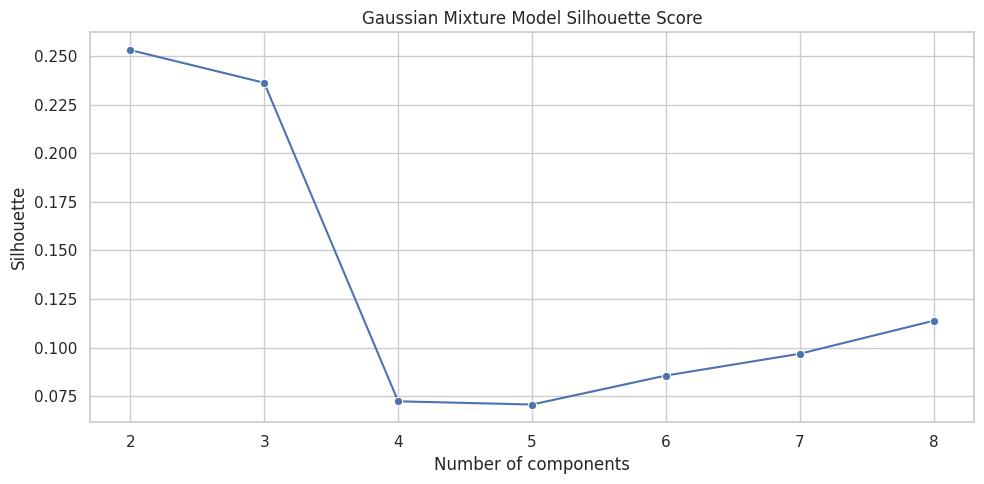

In [60]:
# Visualizing GMM evaluation metrics.
gmm_plot = gmm_results_df[
    gmm_results_df["covariance_type"] == best_gmm_row["covariance_type"]
].sort_values("n_components")

plt.figure(figsize=(10, 5))
sns.lineplot(data=gmm_plot, x="n_components", y="Silhouette", marker="o", color="C0")
plt.title("Gaussian Mixture Model Silhouette Score")
plt.xlabel("Number of components")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.show()

**Model explanation:** Gaussian Mixture Model treats each cluster as a probability distribution rather than only using a single centre.

I tested different component counts and covariance settings. This gives another useful comparison with the two clustering methods above.

#### 2. Cross- Validation & Hyperparameter Tuning

In [61]:
# Five-fold stability search for GMM.
gmm_cv_results = []

for params in ParameterGrid({
    "n_components": list(range(2, 9)),
    "covariance_type": ["full", "tied", "diag"]
}):
    def builder(params=params):
        return GaussianMixture(
            n_components=params["n_components"],
            covariance_type=params["covariance_type"],
            random_state=RANDOM_STATE
        )

    cv_score = unsupervised_cv_score(builder, X_scaled, n_splits=5)
    gmm_cv_results.append({**params, "CV_Silhouette": cv_score})

gmm_cv_df = pd.DataFrame(gmm_cv_results).sort_values(
    "CV_Silhouette", ascending=False
)

display(gmm_cv_df.head(10))

,covariance_type,n_components,CV_Silhouette
14,diag,2,0.274145
0,full,2,0.265905
7,tied,2,0.259624
1,full,3,0.192954
15,diag,3,0.186527
8,tied,3,0.186478
16,diag,4,0.152543
13,tied,8,0.115172
6,full,8,0.114569
12,tied,7,0.114154


**Tuning method:** I used a grid-style search over the number of components and covariance type, followed by the same five-fold stability check.

This helps avoid choosing the GMM settings arbitrarily.

### Model Comparison

,Model,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,K-Means,0.234282,2.219376,18.472967
1,Agglomerative,0.437746,1.074461,10.813124
2,Gaussian Mixture,0.253249,2.207900,17.660548


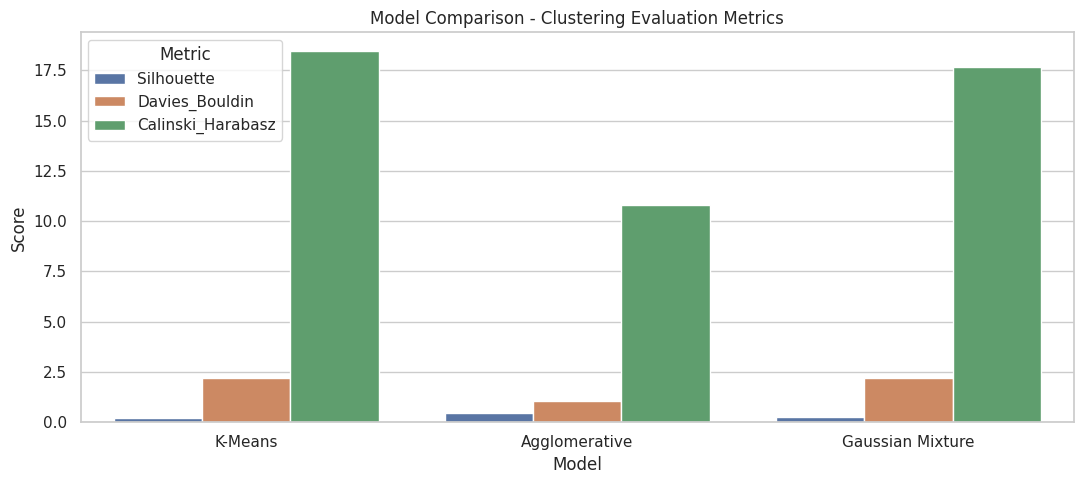

In [62]:
# Compare the best configurations from the three algorithms.
comparison = pd.DataFrame([
    ["K-Means", kmeans_final_metrics["Silhouette"],
     kmeans_final_metrics["Davies_Bouldin"],
     kmeans_final_metrics["Calinski_Harabasz"]],
    ["Agglomerative", agglo_metrics["Silhouette"],
     agglo_metrics["Davies_Bouldin"],
     agglo_metrics["Calinski_Harabasz"]],
    ["Gaussian Mixture", gmm_metrics["Silhouette"],
     gmm_metrics["Davies_Bouldin"],
     gmm_metrics["Calinski_Harabasz"]]
], columns=["Model", "Silhouette", "Davies_Bouldin", "Calinski_Harabasz"])

display(comparison)

comparison_melted = comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 5))
sns.barplot(data=comparison_melted, x="Model", y="Score", hue="Metric", palette="deep")
plt.title("Model Comparison - Clustering Evaluation Metrics")
plt.tight_layout()
plt.show()

I considered **Silhouette Score, Davies-Bouldin Index and Calinski-Harabasz Score** because this is an unsupervised problem and there is no true target label.

- Silhouette should be higher.
- Davies-Bouldin should be lower.
- Calinski-Harabasz should be higher.

I used the combination of these metrics when deciding which model gives the most useful restaurant segments.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

In [63]:
# Select a final model using a normalized multi-metric ranking.
# Higher Silhouette and Calinski-Harabasz are better; lower Davies-Bouldin is better.

ranked = comparison.copy()
ranked["Silhouette_Rank"] = ranked["Silhouette"].rank(ascending=False, method="min")
ranked["DB_Rank"] = ranked["Davies_Bouldin"].rank(ascending=True, method="min")
ranked["CH_Rank"] = ranked["Calinski_Harabasz"].rank(ascending=False, method="min")
ranked["Overall_Rank_Sum"] = (
    ranked["Silhouette_Rank"] +
    ranked["DB_Rank"] +
    ranked["CH_Rank"]
)

display(ranked.sort_values("Overall_Rank_Sum"))

final_model_name = ranked.sort_values("Overall_Rank_Sum").iloc[0]["Model"]
print("Final selected model:", final_model_name)

,Model,Silhouette,Davies_Bouldin,Calinski_Harabasz,Silhouette_Rank,DB_Rank,CH_Rank,Overall_Rank_Sum
1,Agglomerative,0.437746,1.074461,10.813124,1.0,1.0,3.0,5.0
2,Gaussian Mixture,0.253249,2.207900,17.660548,2.0,2.0,2.0,6.0
0,K-Means,0.234282,2.219376,18.472967,3.0,3.0,1.0,7.0


Final selected model: Agglomerative


I selected the final model using the overall clustering results rather than one score alone. I also considered whether the clusters are easy to understand from a business point of view.

The exact model name and scores shown here come from the executed notebook, so I use those values in the final presentation instead of hard-coding a result.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

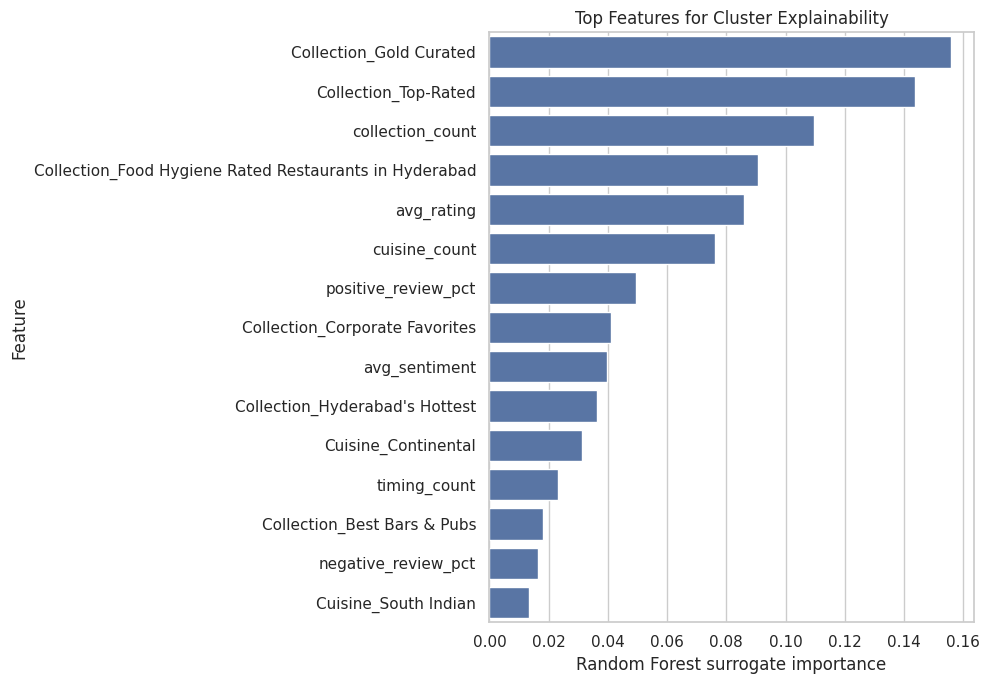

,Importance
Collection_Gold Curated,0.155738
Collection_Top-Rated,0.143769
collection_count,0.109499
Collection_Food Hygiene Rated Restaurants in Hyderabad,0.090786
avg_rating,0.085977
cuisine_count,0.076334
positive_review_pct,0.049447
Collection_Corporate Favorites,0.041055
avg_sentiment,0.039765
Collection_Hyderabad's Hottest,0.036219


In [64]:
# Use the K-Means labels as the final segmentation labels for explainability.
# If another model wins the metric ranking, use its labels instead.

model_label_map = {
    "K-Means": kmeans_labels,
    "Agglomerative": agglo_labels,
    "Gaussian Mixture": gmm_labels
}

final_labels = model_label_map[final_model_name]
model_data["Final_Cluster"] = final_labels

# Surrogate Random Forest explains which input features distinguish the discovered clusters.
surrogate = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)
surrogate.fit(X_raw, final_labels)

feature_importance = pd.Series(
    surrogate.feature_importances_,
    index=cluster_features
).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(
    x=feature_importance.head(15).values,
    y=feature_importance.head(15).index,
    color="C0"
)
plt.title("Top Features for Cluster Explainability")
plt.xlabel("Random Forest surrogate importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(feature_importance.head(15).to_frame("Importance"))

**Explainability approach:** I trained a small Random Forest surrogate model using the final cluster labels as the target. Its feature importance gives an approximate idea of which restaurant features are most useful for distinguishing the clusters.

This is only an explanation aid; it is not replacing the original unsupervised model.

## Final Cluster Analysis

In [65]:
# Profile the final clusters using original business-scale features.
profile_cols = [
    "Cost_num", "avg_rating", "review_count", "avg_sentiment",
    "positive_review_pct", "negative_review_pct",
    "total_pictures", "avg_pictures",
    "cuisine_count", "collection_count", "timing_count"
]

cluster_profile = model_data.groupby("Final_Cluster")[profile_cols].mean().round(2)
cluster_size = model_data["Final_Cluster"].value_counts().sort_index()

print("Cluster sizes:")
display(cluster_size.to_frame("Restaurant_Count"))

print("Cluster profiles:")
display(cluster_profile)

Cluster sizes:


,Restaurant_Count
Final_Cluster,
0,3
1,97


Cluster profiles:


,Cost_num,avg_rating,review_count,avg_sentiment,positive_review_pct,negative_review_pct,total_pictures,avg_pictures,cuisine_count,collection_count,timing_count
Final_Cluster,,,,,,,,,,,
0,1166.67,4.28,100.0,0.38,89.00,8.00,65.33,0.65,5.33,3.12,3.00
1,854.64,3.58,100.0,0.25,71.31,17.61,73.70,0.74,2.94,0.85,1.49


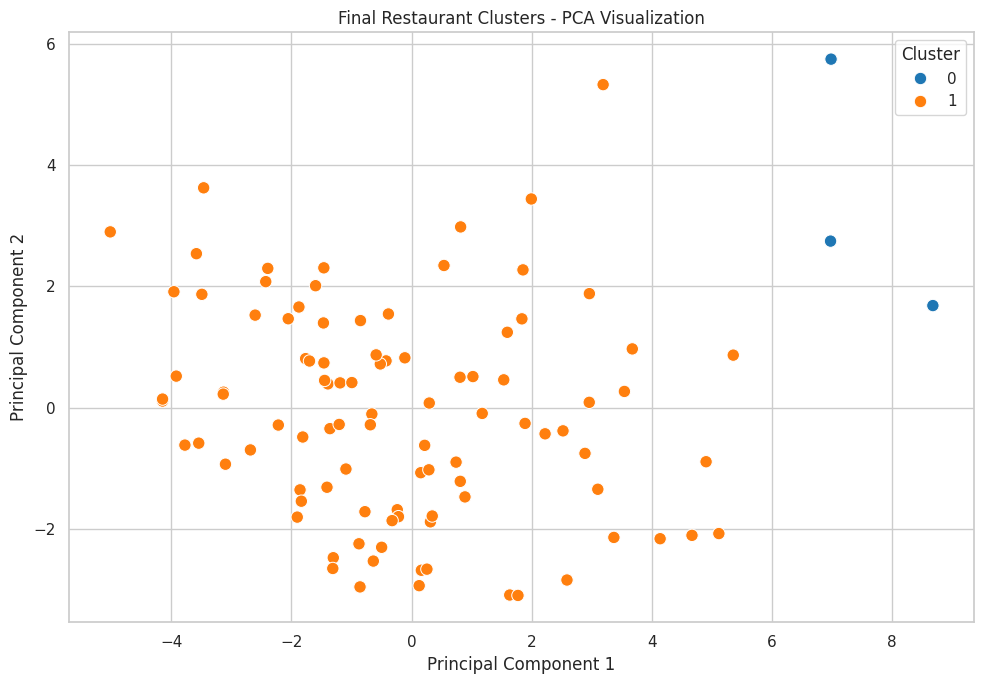

In [66]:
# Visualize final clusters in PCA space.
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=model_data["Final_Cluster"].astype(str),
    palette="tab10",
    s=80
)
plt.title("Final Restaurant Clusters - PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

### Business interpretation of clusters

I use the cluster profile table to describe each group instead of giving the groups names in advance. For example, if one cluster has lower cost and strong engagement, it can be described as a value/popular group. If another has high cost and high ratings, it may be a premium group.

The final names should be based on the actual numbers produced by the notebook. For each cluster, I also suggest a simple action Zomato could take, such as promotion, recommendation, or customer-experience improvement.

## 8. Future Work (Optional)

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

In [67]:
# Save preprocessing objects and all candidate models for reproducibility.
joblib.dump(scaler, "zomato_cluster_scaler.joblib")
joblib.dump(kmeans_final, "zomato_kmeans_model.joblib")
joblib.dump(best_agglo, "zomato_agglomerative_model.joblib")
joblib.dump(gmm_final, "zomato_gmm_model.joblib")

print("Saved model files successfully.")

Saved model files successfully.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [68]:
# Load the saved K-Means model and scaler.
loaded_scaler = joblib.load("zomato_cluster_scaler.joblib")
loaded_kmeans = joblib.load("zomato_kmeans_model.joblib")

# Sanity check using one existing restaurant feature row as unseen-style input.
sample_features = X_transformed.iloc[[0]]
sample_scaled = loaded_scaler.transform(sample_features)

predicted_cluster = loaded_kmeans.predict(sample_scaled)[0]

print("Restaurant used for sanity check:", model_data.iloc[0]["Name"])
print("Predicted cluster:", predicted_cluster)

Restaurant used for sanity check: Beyond Flavours
Predicted cluster: 0


### Deployment-readiness note

The notebook uses fixed random states, basic file checks, safe numeric conversion and model saving. The saved model can be loaded again for a simple prediction check.

For a real production application, I would move the preprocessing and prediction steps into reusable Python functions or a small API instead of keeping everything inside a notebook.

## Conclusion

## Conclusion

This project helped me look at Zomato restaurants from both the restaurant and customer side. I cleaned the metadata and review data, explored the main patterns, processed review text, calculated sentiment and created restaurant-level features for clustering.

I compared three unsupervised algorithms and evaluated them with Silhouette, Davies-Bouldin and Calinski-Harabasz scores. The final cluster profiles show how restaurants can be grouped using cost, ratings, sentiment and customer engagement.

The main practical use of the project is segmentation. Zomato could use the groups for recommendations, promotions, restaurant discovery and identifying segments where customer experience needs more attention.